# Base CNN Architecture

In [ ]:
!pip install tensorflow
!pip install numpy
!pip install pandas
!pip install matplotlib
!pip install pydot

In [ ]:
import os

folder_name = 'hair_types'

if os.path.isdir(folder_name):
    print(f"Contents of '{folder_name}':")
    for item in os.listdir(folder_name):
        print(f"- {item}")
else:
    print(f"Folder '{folder_name}' not found in the same directory.")

In [ ]:
print(f"Current working directory: {os.getcwd()}")

In [ ]:
print(f"Contents of current directory: {os.listdir()}")

In [1]:
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers
from keras.models import Sequential
from keras.layers import Dense
from keras.utils import model_to_dot
from IPython.display import Image, display, SVG

In [2]:
from pathlib import Path
import imghdr
import os

data_dir = "hair_types"  # Directly target the hair_types folder
image_extensions = {".jpg", ".jpeg", ".png", ".gif"}

for hair_type_folder in os.listdir(data_dir):
    hair_type_path = os.path.join(data_dir, hair_type_folder)
    if os.path.isdir(hair_type_path):
        print(f"Processing folder: {hair_type_path}")
        for filename in os.listdir(hair_type_path):
            filepath = os.path.join(hair_type_path, filename)
            if Path(filepath).suffix.lower() in image_extensions:
                print(f"Trying to open: {filepath}")
                try:
                    img_type = imghdr.what(filepath)
                    if img_type is None:
                        print(f"{filepath} is not a recognized image format")
                except FileNotFoundError as e:
                    print(f"Error opening {filepath}: {e}")

C:\Users\HomePC\AppData\Local\Temp\ipykernel_19328\3251977125.py:2: DeprecationWarning: 'imghdr' is deprecated and slated for removal in Python 3.13
  import imghdr


Processing folder: hair_types\Curly_Hair
Trying to open: hair_types\Curly_Hair\02dac897d1dec9ba8c057a11d041ada8--layered-natural-hair-natural-black-hairstyles.jpg
Trying to open: hair_types\Curly_Hair\08de1b46cf5693bd811b7ca7d72484ff.jpg
Trying to open: hair_types\Curly_Hair\0b7aa42d28a71654681bfd13b569ce32.jpg
Trying to open: hair_types\Curly_Hair\0dba94f77ba91fe4c546048f7476c0ed--curly-hair-cuts-bangs-curly-hair-fringe.jpg
Trying to open: hair_types\Curly_Hair\120047603-selfie-photo-of-curly-haired-caucasian-girl-watching-smilingly-into-camera-and-winking-at-it-in-sunn.jpg
Trying to open: hair_types\Curly_Hair\120047608-selfie-photo-of-cute-curly-haired-caucasian-girl-watching-calmly-into-camera-and-flirting-with-it-in.jpg
Trying to open: hair_types\Curly_Hair\12345722_1638604416406814_170629318_n.jpg
Trying to open: hair_types\Curly_Hair\129aa0f078ba4621e7b33bbe68fae650.jpg
Trying to open: hair_types\Curly_Hair\1369382420_42389.jpg
Trying to open: hair_types\Curly_Hair\138370-Frizzy

In [3]:
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers

image_size = (64, 64)
batch_size = 32

train_ds = tf.keras.preprocessing.image_dataset_from_directory(
    "hair_types/",
    validation_split=0.2,
    subset="training",
    seed=1337,
    image_size=image_size,
    batch_size=batch_size,
    labels='inferred',
    label_mode='categorical'
)

val_ds = tf.keras.preprocessing.image_dataset_from_directory(
    "hair_types/",
    validation_split=0.2,
    subset="validation",
    seed=1337,
    image_size=image_size,
    batch_size=batch_size,
    labels='inferred',
    label_mode='categorical'
)

Found 985 files belonging to 3 classes.
Using 788 files for training.
Found 985 files belonging to 3 classes.
Using 197 files for validation.


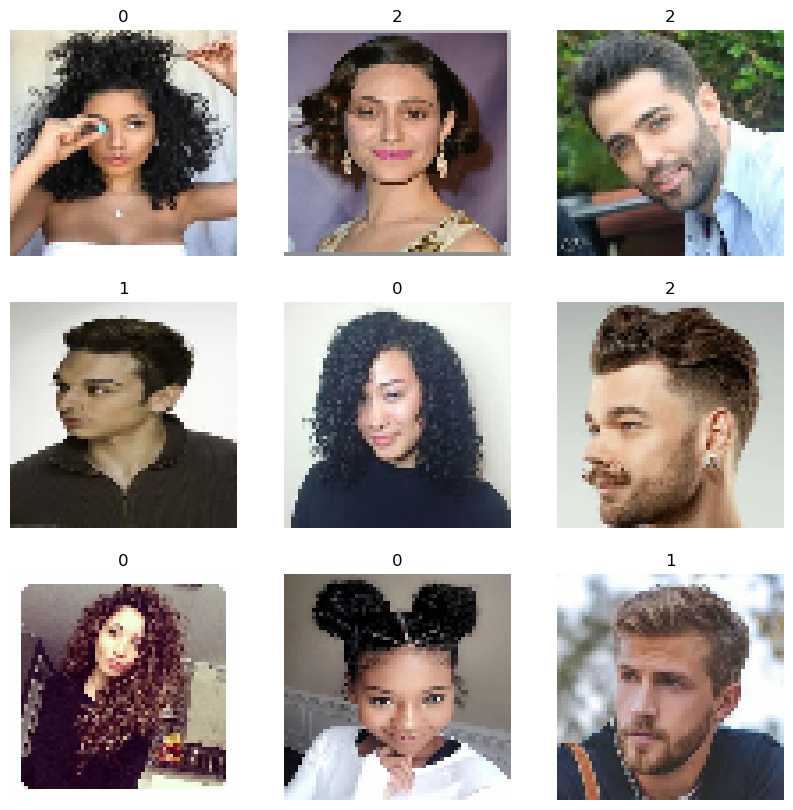

In [4]:
import matplotlib.pyplot as plt
import numpy as np

plt.figure(figsize=(10, 10))
for images, labels in train_ds.take(1):
    for i in range(9):
        ax = plt.subplot(3, 3, i + 1)
        plt.imshow(images[i].numpy().astype("uint8"))
        plt.title(int(np.argmax(labels[i])))
        plt.axis("off")
plt.show()

In [5]:
from sklearn.metrics import classification_report, confusion_matrix, roc_auc_score

def evaluate_model(model, dataset, dataset_name="Dataset"):
    y_true = []
    y_pred = []
    y_prob = []

    for images, labels in dataset:
        preds = model.predict(images, verbose=0)
        y_prob.extend(preds)
        y_pred.extend(np.argmax(preds, axis=1))
        y_true.extend(np.argmax(labels.numpy(), axis=1))

    y_true = np.array(y_true)
    y_pred = np.array(y_pred)
    y_prob = np.array(y_prob)

    print(f"\n===== {dataset_name} Evaluation =====")
    print("Classification Report:")
    print(classification_report(y_true, y_pred))

    # Confusion matrix for specificity
    cm = confusion_matrix(y_true, y_pred)
    FP = cm.sum(axis=0) - np.diag(cm)
    FN = cm.sum(axis=1) - np.diag(cm)
    TP = np.diag(cm)
    TN = cm.sum() - (FP + FN + TP)
    specificity = np.where((TN + FP) != 0, TN / (TN + FP), 0.0)
    print("Specificity (per class):", specificity)

    # ROC AUC (macro average for multiclass)
    roc_auc = roc_auc_score(y_true, y_prob, multi_class='ovr', average='macro')
    print("ROC-AUC (macro average):", roc_auc)

    return {
        "classification_report": classification_report(y_true, y_pred, output_dict=True),
        "specificity": specificity,
        "roc_auc": roc_auc
    }

In [6]:
model = Sequential()
model.add(keras.Input(shape=image_size + (3,))) # 64, 64, 3
model.add(layers.Rescaling(1.0 / 255))

model.add(layers.Conv2D(filters=4, kernel_size=16, strides=1, padding='valid', dilation_rate=1))
model.add(layers.Activation("relu"))

model.add(layers.Conv2D(filters=8, kernel_size=8, strides=1, padding='valid', dilation_rate=1))
model.add(layers.Activation("relu"))

model.add(layers.Conv2D(filters=16, kernel_size=4, strides=1, padding='valid', dilation_rate=1))
model.add(layers.Activation("relu"))

model.add(layers.GlobalAveragePooling2D())
model.add(layers.Dense(64))
model.add(layers.Activation("relu"))
model.add(layers.Dense(3))
model.add(layers.Activation("softmax"))

tf.keras.utils.plot_model(model, to_file='model_test.png', show_shapes=True)

epochs = 50

model.compile(
    optimizer=keras.optimizers.Adam(1e-3),
    loss="categorical_crossentropy",
    metrics=["accuracy"],
)
model.fit(train_ds, epochs=epochs, validation_data=val_ds)

You must install graphviz (see instructions at https://graphviz.gitlab.io/download/) for `plot_model` to work.
Epoch 1/50
25/25 ━━━━━━━━━━━━━━━━━━━━ 3s 59ms/step - accuracy: 0.3576 - loss: 1.0975 - val_accuracy: 0.2843 - val_loss: 1.0931
Epoch 2/50
25/25 ━━━━━━━━━━━━━━━━━━━━ 1s 51ms/step - accuracy: 0.3629 - loss: 1.0692 - val_accuracy: 0.3858 - val_loss: 1.0781
Epoch 3/50
25/25 ━━━━━━━━━━━━━━━━━━━━ 1s 55ms/step - accuracy: 0.4424 - loss: 1.0513 - val_accuracy: 0.3655 - val_loss: 1.1025
Epoch 4/50
25/25 ━━━━━━━━━━━━━━━━━━━━ 1s 53ms/step - accuracy: 0.4725 - loss: 1.0389 - val_accuracy: 0.4264 - val_loss: 1.0612
Epoch 5/50
25/25 ━━━━━━━━━━━━━━━━━━━━ 1s 53ms/step - accuracy: 0.4973 - loss: 1.0088 - val_accuracy: 0.4365 - val_loss: 1.0619
Epoch 6/50
25/25 ━━━━━━━━━━━━━━━━━━━━ 1s 53ms/step - accuracy: 0.4552 - loss: 1.0044 - val_accuracy: 0.4416 - val_loss: 1.0319
Epoch 7/50
25/25 ━━━━━━━━━━━━━━━━━━━━ 1s 54ms/step - accuracy: 0.4997 - loss: 0.9705 - val_accuracy: 0.4569 - val_loss: 1.0364


## Baseline Prediction

In [8]:
img = keras.preprocessing.image.load_img(
    "hair_types/Curly_Hair/02dac897d1dec9ba8c057a11d041ada8--layered-natural-hair-natural-black-hairstyles.jpg", target_size=image_size
)
img_array = keras.preprocessing.image.img_to_array(img)
img_array = tf.expand_dims(img_array, 0)  # Create batch axis

predictions = model.predict(img_array)
print(
    "This image is %.2f percent curly hair, %.2f percent straight hair, and %.2f percent wavy hair."
    % tuple(predictions[0])
)


1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 78ms/step
This image is 0.85 percent curly hair, 0.14 percent straight hair, and 0.02 percent wavy hair.


In [9]:
img = keras.preprocessing.image.load_img(
    "hair_types/Straight_Hair/01-10-2019-latest-haircut-for-girls_Equal_Length_4PNG.jpg", target_size=image_size
)
img_array = keras.preprocessing.image.img_to_array(img)
img_array = tf.expand_dims(img_array, 0)  # Create batch axis

predictions = model.predict(img_array)
print(
    "This image is %.2f percent curly hair, %.2f percent straight hair, and %.2f percent wavy hair."
    % tuple(predictions[0])
)

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 32ms/step
This image is 0.68 percent curly hair, 0.22 percent straight hair, and 0.10 percent wavy hair.


In [10]:
img = keras.preprocessing.image.load_img(
    "hair_types/Wavy_Hair/images(1).jpg", target_size=image_size
)
img_array = keras.preprocessing.image.img_to_array(img)
img_array = tf.expand_dims(img_array, 0)  # Create batch axis

predictions = model.predict(img_array)
print(
    "This image is %.2f percent curly hair, %.2f percent straight hair, and %.2f percent wavy hair."
    % tuple(predictions[0])
)

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 21ms/step
This image is 0.03 percent curly hair, 0.48 percent straight hair, and 0.49 percent wavy hair.


In [11]:
results_baseline_train = evaluate_model(model, train_ds, dataset_name="Baseline Model - Training")


===== Baseline Model - Training Evaluation =====
Classification Report:
              precision    recall  f1-score   support

           0       0.74      0.75      0.74       276
           1       0.59      0.60      0.59       252
           2       0.57      0.55      0.56       260

    accuracy                           0.63       788
   macro avg       0.63      0.63      0.63       788
weighted avg       0.63      0.63      0.63       788

Specificity (per class): [0.85546875 0.80223881 0.79356061]
ROC-AUC (macro average): 0.8080351840273675


In [12]:
results_baseline_val = evaluate_model(model, val_ds, dataset_name="Baseline Model - Validation")


===== Baseline Model - Validation Evaluation =====
Classification Report:
              precision    recall  f1-score   support

           0       0.48      0.55      0.52        56
           1       0.48      0.47      0.47        70
           2       0.45      0.41      0.43        71

    accuracy                           0.47       197
   macro avg       0.47      0.48      0.47       197
weighted avg       0.47      0.47      0.47       197

Specificity (per class): [0.76595745 0.71653543 0.72222222]
ROC-AUC (macro average): 0.671496148637199


## Analysis and Conclusion
### How did the baseline perform?

accuracy: 0.6152 
val_accuracy: 0.5127

This initial performance suggests that the model started with a classification accuracy that is only slightly better than random guessing (which would be around 33.33% for three classes). The high initial loss further indicates that the model was not confident in its initial predictions.

Therefore, the baseline performance was quite poor, indicating that the model needed significant training to learn to distinguish between the different hair types. The large gap between the training and validation accuracy in the initial epochs isn't a major concern at this stage, as both are low, suggesting the model is underfitting. As training progresses, we would hope to see both accuracy values increase and the loss values decrease.

# Scratch CNN Model
## Using the base model with the Researchers Changes

## Experiment 1 (Other Preprocessing Methods for Images)

### Experiment 1.1 (Different Image Rescaling)

In [18]:
model_exp1_1 = Sequential()
model_exp1_1.add(keras.Input(shape=image_size + (3,))) # 64, 64, 3
model_exp1_1.add(layers.Normalization(mean=0.0, variance=1.0)) # Replaced the existing Rescaling layer with this


model_exp1_1.add(layers.Conv2D(filters=4, kernel_size=16, strides=1, padding='valid', dilation_rate=1))
model_exp1_1.add(layers.Activation("relu"))

model_exp1_1.add(layers.Conv2D(filters=8, kernel_size=8, strides=1, padding='valid', dilation_rate=1))
model_exp1_1.add(layers.Activation("relu"))

model_exp1_1.add(layers.Conv2D(filters=16, kernel_size=4, strides=1, padding='valid', dilation_rate=1))
model_exp1_1.add(layers.Activation("relu"))

model_exp1_1.add(layers.GlobalAveragePooling2D())
model_exp1_1.add(layers.Dense(64))
model_exp1_1.add(layers.Activation("relu"))
model_exp1_1.add(layers.Dense(3))
model_exp1_1.add(layers.Activation("softmax"))

tf.keras.utils.plot_model(model_exp1_1, to_file='model_test_1_1.png', show_shapes=True)

epochs = 50

model_exp1_1.compile(
    optimizer=keras.optimizers.Adam(1e-3),
    loss="categorical_crossentropy",
    metrics=["accuracy"],
)
model_exp1_1.fit(train_ds, epochs=epochs, validation_data=val_ds)

You must install graphviz (see instructions at https://graphviz.gitlab.io/download/) for `plot_model` to work.
Epoch 1/50
25/25 ━━━━━━━━━━━━━━━━━━━━ 3s 58ms/step - accuracy: 0.3200 - loss: 6.9883 - val_accuracy: 0.2843 - val_loss: 1.1009
Epoch 2/50
25/25 ━━━━━━━━━━━━━━━━━━━━ 1s 47ms/step - accuracy: 0.3517 - loss: 1.0982 - val_accuracy: 0.2843 - val_loss: 1.1019
Epoch 3/50
25/25 ━━━━━━━━━━━━━━━━━━━━ 1s 52ms/step - accuracy: 0.3356 - loss: 1.0988 - val_accuracy: 0.2843 - val_loss: 1.1021
Epoch 4/50
25/25 ━━━━━━━━━━━━━━━━━━━━ 1s 52ms/step - accuracy: 0.3304 - loss: 1.0991 - val_accuracy: 0.2843 - val_loss: 1.1017
Epoch 5/50
25/25 ━━━━━━━━━━━━━━━━━━━━ 1s 50ms/step - accuracy: 0.3559 - loss: 1.0976 - val_accuracy: 0.2843 - val_loss: 1.1032
Epoch 6/50
25/25 ━━━━━━━━━━━━━━━━━━━━ 1s 52ms/step - accuracy: 0.3424 - loss: 1.0984 - val_accuracy: 0.2843 - val_loss: 1.1018
Epoch 7/50
25/25 ━━━━━━━━━━━━━━━━━━━━ 1s 53ms/step - accuracy: 0.3530 - loss: 1.0978 - val_accuracy: 0.2843 - val_loss: 1.1029


#### Experiment 1.1 Prediction

In [20]:
img = keras.preprocessing.image.load_img(
    "hair_types/Curly_Hair/02dac897d1dec9ba8c057a11d041ada8--layered-natural-hair-natural-black-hairstyles.jpg", target_size=image_size
)
img_array = keras.preprocessing.image.img_to_array(img)
img_array = tf.expand_dims(img_array, 0)  # Create batch axis

predictions = model_exp1_1.predict(img_array)
print(
    "This image is %.2f percent curly hair, %.2f percent straight hair, and %.2f percent wavy hair."
    % tuple(predictions[0])
)


1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 72ms/step
This image is 0.35 percent curly hair, 0.32 percent straight hair, and 0.33 percent wavy hair.


In [21]:
img = keras.preprocessing.image.load_img(
    "hair_types/Straight_Hair/01-10-2019-latest-haircut-for-girls_Equal_Length_4PNG.jpg", target_size=image_size
)
img_array = keras.preprocessing.image.img_to_array(img)
img_array = tf.expand_dims(img_array, 0)  # Create batch axis

predictions = model_exp1_1.predict(img_array)
print(
    "This image is %.2f percent curly hair, %.2f percent straight hair, and %.2f percent wavy hair."
    % tuple(predictions[0])
)

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 21ms/step
This image is 0.35 percent curly hair, 0.32 percent straight hair, and 0.33 percent wavy hair.


In [22]:
img = keras.preprocessing.image.load_img(
    "hair_types/Wavy_Hair/images(1).jpg", target_size=image_size
)
img_array = keras.preprocessing.image.img_to_array(img)
img_array = tf.expand_dims(img_array, 0)  # Create batch axis

predictions = model_exp1_1.predict(img_array)
print(
    "This image is %.2f percent curly hair, %.2f percent straight hair, and %.2f percent wavy hair."
    % tuple(predictions[0])
)

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 21ms/step
This image is 0.35 percent curly hair, 0.32 percent straight hair, and 0.33 percent wavy hair.


In [23]:
results_model_exp1_1_train = evaluate_model(model_exp1_1, train_ds, dataset_name="Experiment 1.1 - Training")


===== Experiment 1.1 - Training Evaluation =====
Classification Report:
              precision    recall  f1-score   support

           0       0.35      1.00      0.52       276
           1       0.71      0.02      0.04       252
           2       0.00      0.00      0.00       260

    accuracy                           0.36       788
   macro avg       0.36      0.34      0.19       788
weighted avg       0.35      0.36      0.19       788

Specificity (per class): [0.01171875 0.99626866 1.        ]
ROC-AUC (macro average): 0.5067723142009699


C:\Users\HomePC\anaconda3\envs\UST_DATASCIENCE\Lib\site-packages\sklearn\metrics\_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
C:\Users\HomePC\anaconda3\envs\UST_DATASCIENCE\Lib\site-packages\sklearn\metrics\_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
C:\Users\HomePC\anaconda3\envs\UST_DATASCIENCE\Lib\site-packages\sklearn\metrics\_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capita

In [24]:
results_model_exp1_1_val = evaluate_model(model_exp1_1, val_ds, dataset_name="Experiment 1.1 - Validation")


===== Experiment 1.1 - Validation Evaluation =====
Classification Report:
              precision    recall  f1-score   support

           0       0.28      0.98      0.44        56
           1       0.00      0.00      0.00        70
           2       0.00      0.00      0.00        71

    accuracy                           0.28       197
   macro avg       0.09      0.33      0.15       197
weighted avg       0.08      0.28      0.12       197

Specificity (per class): [0.         0.99212598 1.        ]
ROC-AUC (macro average): 0.5018801062987693


C:\Users\HomePC\anaconda3\envs\UST_DATASCIENCE\Lib\site-packages\sklearn\metrics\_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
C:\Users\HomePC\anaconda3\envs\UST_DATASCIENCE\Lib\site-packages\sklearn\metrics\_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
C:\Users\HomePC\anaconda3\envs\UST_DATASCIENCE\Lib\site-packages\sklearn\metrics\_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capita

### Experiment 1.2 (Scaling to the Range [-1, 1])

In [26]:
model_exp1_2 = Sequential()
model_exp1_2.add(keras.Input(shape=image_size + (3,))) # 64, 64, 3
model_exp1_2.add(layers.Rescaling(scale=1.0/127.5, offset=-1)) # Replaced the existing Rescaling layer with this


model_exp1_2.add(layers.Conv2D(filters=4, kernel_size=16, strides=1, padding='valid', dilation_rate=1))
model_exp1_2.add(layers.Activation("relu"))

model_exp1_2.add(layers.Conv2D(filters=8, kernel_size=8, strides=1, padding='valid', dilation_rate=1))
model_exp1_2.add(layers.Activation("relu"))

model_exp1_2.add(layers.Conv2D(filters=16, kernel_size=4, strides=1, padding='valid', dilation_rate=1))
model_exp1_2.add(layers.Activation("relu"))

model_exp1_2.add(layers.GlobalAveragePooling2D())
model_exp1_2.add(layers.Dense(64))
model_exp1_2.add(layers.Activation("relu"))
model_exp1_2.add(layers.Dense(3))
model_exp1_2.add(layers.Activation("softmax"))

tf.keras.utils.plot_model(model_exp1_2, to_file='model_test_1_2.png', show_shapes=True)

epochs = 50

model_exp1_2.compile(
    optimizer=keras.optimizers.Adam(1e-3),
    loss="categorical_crossentropy",
    metrics=["accuracy"],
)
model_exp1_2.fit(train_ds, epochs=epochs, validation_data=val_ds)

You must install graphviz (see instructions at https://graphviz.gitlab.io/download/) for `plot_model` to work.
Epoch 1/50
25/25 ━━━━━━━━━━━━━━━━━━━━ 3s 61ms/step - accuracy: 0.4114 - loss: 1.0760 - val_accuracy: 0.4061 - val_loss: 1.0728
Epoch 2/50
25/25 ━━━━━━━━━━━━━━━━━━━━ 1s 54ms/step - accuracy: 0.5159 - loss: 1.0230 - val_accuracy: 0.4416 - val_loss: 1.0389
Epoch 3/50
25/25 ━━━━━━━━━━━━━━━━━━━━ 1s 53ms/step - accuracy: 0.5213 - loss: 0.9823 - val_accuracy: 0.4365 - val_loss: 1.0263
Epoch 4/50
25/25 ━━━━━━━━━━━━━━━━━━━━ 1s 53ms/step - accuracy: 0.5199 - loss: 0.9721 - val_accuracy: 0.5127 - val_loss: 1.0124
Epoch 5/50
25/25 ━━━━━━━━━━━━━━━━━━━━ 1s 53ms/step - accuracy: 0.5446 - loss: 0.9597 - val_accuracy: 0.4518 - val_loss: 1.0594
Epoch 6/50
25/25 ━━━━━━━━━━━━━━━━━━━━ 1s 53ms/step - accuracy: 0.5528 - loss: 0.9638 - val_accuracy: 0.5482 - val_loss: 0.9609
Epoch 7/50
25/25 ━━━━━━━━━━━━━━━━━━━━ 1s 54ms/step - accuracy: 0.5526 - loss: 0.9177 - val_accuracy: 0.5076 - val_loss: 0.9723


#### Experiment 1.2 Prediction

In [28]:
img = keras.preprocessing.image.load_img(
    "hair_types/Curly_Hair/02dac897d1dec9ba8c057a11d041ada8--layered-natural-hair-natural-black-hairstyles.jpg", target_size=image_size
)
img_array = keras.preprocessing.image.img_to_array(img)
img_array = tf.expand_dims(img_array, 0)  # Create batch axis

predictions = model_exp1_2.predict(img_array)
print(
    "This image is %.2f percent curly hair, %.2f percent straight hair, and %.2f percent wavy hair."
    % tuple(predictions[0])
)


1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 81ms/step
This image is 0.98 percent curly hair, 0.02 percent straight hair, and 0.00 percent wavy hair.


In [29]:
img = keras.preprocessing.image.load_img(
    "hair_types/Straight_Hair/01-10-2019-latest-haircut-for-girls_Equal_Length_4PNG.jpg", target_size=image_size
)
img_array = keras.preprocessing.image.img_to_array(img)
img_array = tf.expand_dims(img_array, 0)  # Create batch axis

predictions = model_exp1_2.predict(img_array)
print(
    "This image is %.2f percent curly hair, %.2f percent straight hair, and %.2f percent wavy hair."
    % tuple(predictions[0])
)

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 30ms/step
This image is 0.49 percent curly hair, 0.23 percent straight hair, and 0.28 percent wavy hair.


In [30]:
img = keras.preprocessing.image.load_img(
    "hair_types/Wavy_Hair/images(1).jpg", target_size=image_size
)
img_array = keras.preprocessing.image.img_to_array(img)
img_array = tf.expand_dims(img_array, 0)  # Create batch axis

predictions = model_exp1_2.predict(img_array)
print(
    "This image is %.2f percent curly hair, %.2f percent straight hair, and %.2f percent wavy hair."
    % tuple(predictions[0])
)

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 24ms/step
This image is 0.00 percent curly hair, 0.48 percent straight hair, and 0.52 percent wavy hair.


In [31]:
results_model_exp1_2_train = evaluate_model(model_exp1_2, train_ds, dataset_name="Experiment 1.2 - Training")


===== Experiment 1.2 - Training Evaluation =====
Classification Report:
              precision    recall  f1-score   support

           0       0.74      0.88      0.81       276
           1       0.67      0.56      0.61       252
           2       0.64      0.62      0.63       260

    accuracy                           0.69       788
   macro avg       0.69      0.69      0.68       788
weighted avg       0.69      0.69      0.69       788

Specificity (per class): [0.83789062 0.86940299 0.82954545]
ROC-AUC (macro average): 0.8649579449899035


In [32]:
results_model_exp1_2_val = evaluate_model(model_exp1_2, val_ds, dataset_name="Experiment 1.2 - Validation")


===== Experiment 1.2 - Validation Evaluation =====
Classification Report:
              precision    recall  f1-score   support

           0       0.60      0.71      0.65        56
           1       0.57      0.51      0.54        70
           2       0.54      0.51      0.52        71

    accuracy                           0.57       197
   macro avg       0.57      0.58      0.57       197
weighted avg       0.57      0.57      0.57       197

Specificity (per class): [0.80851064 0.78740157 0.75396825]
ROC-AUC (macro average): 0.7489500416558409


### Experiment 1.3 (Using Integer Lookup for Faster Rescaling)

In [34]:
# Define a lookup table to scale integers from 0-255 to 0-1
scale_lookup = tf.constant([i / 255.0 for i in range(256)], dtype=tf.float32)

def scale_image(image):
    # Use tf.gather to perform the lookup on each pixel value
    scaled_image = tf.gather(scale_lookup, tf.cast(image, tf.int32))
    return scaled_image

def preprocess(image, label):
    scaled_image = scale_image(image)
    return scaled_image, label

train_ds_scaled_lookup = train_ds.map(preprocess)
val_ds_scaled_lookup = val_ds.map(preprocess)

In [35]:
model_exp1_3 = Sequential()
model_exp1_3.add(keras.Input(shape=image_size + (3,))) # 64, 64, 3
# No explicit Rescaling layer needed now as scaling is in the map function


model_exp1_3.add(layers.Conv2D(filters=4, kernel_size=16, strides=1, padding='valid', dilation_rate=1))
model_exp1_3.add(layers.Activation("relu"))

model_exp1_3.add(layers.Conv2D(filters=8, kernel_size=8, strides=1, padding='valid', dilation_rate=1))
model_exp1_3.add(layers.Activation("relu"))

model_exp1_3.add(layers.Conv2D(filters=16, kernel_size=4, strides=1, padding='valid', dilation_rate=1))
model_exp1_3.add(layers.Activation("relu"))

model_exp1_3.add(layers.GlobalAveragePooling2D())
model_exp1_3.add(layers.Dense(64))
model_exp1_3.add(layers.Activation("relu"))
model_exp1_3.add(layers.Dense(3))
model_exp1_3.add(layers.Activation("softmax"))

tf.keras.utils.plot_model(model_exp1_3, to_file='model_test_1_3.png', show_shapes=True)

epochs = 50

model_exp1_3.compile(
    optimizer=keras.optimizers.Adam(1e-3),
    loss="categorical_crossentropy",
    metrics=["accuracy"],
)
model_exp1_3.fit(train_ds_scaled_lookup, epochs=epochs, validation_data=val_ds_scaled_lookup)

You must install graphviz (see instructions at https://graphviz.gitlab.io/download/) for `plot_model` to work.
Epoch 1/50
25/25 ━━━━━━━━━━━━━━━━━━━━ 3s 61ms/step - accuracy: 0.3172 - loss: 1.1001 - val_accuracy: 0.2843 - val_loss: 1.0982
Epoch 2/50
25/25 ━━━━━━━━━━━━━━━━━━━━ 1s 52ms/step - accuracy: 0.3282 - loss: 1.0939 - val_accuracy: 0.2843 - val_loss: 1.0937
Epoch 3/50
25/25 ━━━━━━━━━━━━━━━━━━━━ 1s 54ms/step - accuracy: 0.3734 - loss: 1.0662 - val_accuracy: 0.3198 - val_loss: 1.1734
Epoch 4/50
25/25 ━━━━━━━━━━━━━━━━━━━━ 1s 51ms/step - accuracy: 0.3992 - loss: 1.0977 - val_accuracy: 0.3858 - val_loss: 1.0957
Epoch 5/50
25/25 ━━━━━━━━━━━━━━━━━━━━ 1s 51ms/step - accuracy: 0.4380 - loss: 1.0820 - val_accuracy: 0.3756 - val_loss: 1.0974
Epoch 6/50
25/25 ━━━━━━━━━━━━━━━━━━━━ 1s 52ms/step - accuracy: 0.4693 - loss: 1.0419 - val_accuracy: 0.3858 - val_loss: 1.0759
Epoch 7/50
25/25 ━━━━━━━━━━━━━━━━━━━━ 1s 51ms/step - accuracy: 0.5144 - loss: 1.0401 - val_accuracy: 0.4010 - val_loss: 1.0786


#### Experiment 1.3 Prediction

In [37]:
img = keras.preprocessing.image.load_img(
    "hair_types/Curly_Hair/02dac897d1dec9ba8c057a11d041ada8--layered-natural-hair-natural-black-hairstyles.jpg", target_size=image_size
)
img_array = keras.preprocessing.image.img_to_array(img)
img_array = tf.expand_dims(img_array, 0)  # Create batch axis

predictions = model_exp1_3.predict(img_array)
print(
    "This image is %.2f percent curly hair, %.2f percent straight hair, and %.2f percent wavy hair."
    % tuple(predictions[0])
)


1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 59ms/step
This image is 1.00 percent curly hair, 0.00 percent straight hair, and 0.00 percent wavy hair.


In [38]:
img = keras.preprocessing.image.load_img(
    "hair_types/Straight_Hair/01-10-2019-latest-haircut-for-girls_Equal_Length_4PNG.jpg", target_size=image_size
)
img_array = keras.preprocessing.image.img_to_array(img)
img_array = tf.expand_dims(img_array, 0)  # Create batch axis

predictions = model_exp1_3.predict(img_array)
print(
    "This image is %.2f percent curly hair, %.2f percent straight hair, and %.2f percent wavy hair."
    % tuple(predictions[0])
)

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 20ms/step
This image is 1.00 percent curly hair, 0.00 percent straight hair, and 0.00 percent wavy hair.


In [39]:
img = keras.preprocessing.image.load_img(
    "hair_types/Wavy_Hair/images(1).jpg", target_size=image_size
)
img_array = keras.preprocessing.image.img_to_array(img)
img_array = tf.expand_dims(img_array, 0)  # Create batch axis

predictions = model_exp1_3.predict(img_array)
print(
    "This image is %.2f percent curly hair, %.2f percent straight hair, and %.2f percent wavy hair."
    % tuple(predictions[0])
)

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 21ms/step
This image is 0.10 percent curly hair, 0.51 percent straight hair, and 0.39 percent wavy hair.


In [40]:
results_model_exp1_3_train = evaluate_model(model_exp1_3, train_ds_scaled_lookup, dataset_name="Experiment 1.3 - Training")


===== Experiment 1.3 - Training Evaluation =====
Classification Report:
              precision    recall  f1-score   support

           0       0.62      0.78      0.69       276
           1       0.56      0.51      0.53       252
           2       0.51      0.41      0.45       260

    accuracy                           0.57       788
   macro avg       0.56      0.57      0.56       788
weighted avg       0.56      0.57      0.56       788

Specificity (per class): [0.74023438 0.81156716 0.8030303 ]
ROC-AUC (macro average): 0.7440895189884724


In [41]:
results_model_exp1_3_val = evaluate_model(model_exp1_3, val_ds_scaled_lookup, dataset_name="Experiment 1.3 - Validation")


===== Experiment 1.3 - Validation Evaluation =====
Classification Report:
              precision    recall  f1-score   support

           0       0.40      0.64      0.50        56
           1       0.48      0.39      0.43        70
           2       0.40      0.30      0.34        71

    accuracy                           0.43       197
   macro avg       0.43      0.44      0.42       197
weighted avg       0.43      0.43      0.42       197

Specificity (per class): [0.62411348 0.77165354 0.75396825]
ROC-AUC (macro average): 0.6553599416157786


### Experiment 1 Analysis and Conclusion
#### How did the Experiment 1 perform?

| Experiment | Preprocessing Type                | Train Acc | Val Acc | Notes                                      |
|------------|-----------------------------------|-----------|---------|--------------------------------------------|
| 1.1        | `Normalization(mean=0, var=1)`    | 0.6269    | 0.4619  | Weak; normalization ineffective            |
| 1.2        | Rescaling to [-1, 1]              | 0.6706    | 0.5635  | Best performance, better generalization |
| 1.3        | Custom scaling to [0, 1]          | 0.5173    | 0.4619  | Overconfident predictions, lower accuracy  |

##### Experiment 1.1
Model is underperforming, with both training and validation accuracy close to random chance (33%), indicating potential issues with how normalization was applied.

##### Experiment 1.2
Best-performing model among the three, Rescaling the input to [-1, 1] likely helped stabilize training. Still signs of overfitting (train accuracy >> val accuracy), but generalization is improved.

##### Experiment 1.3
Scaling is technically correct, but might not provide the best numerical range for CNNs (e.g., [-1, 1] often works better). Inference result shows overconfidence, a sign of poor calibration or weak generalization.

##### Conclusion
Experiment 1.2 performed the best in terms of training stability, accuracy, and sensible inference outputs. The rescaling to [-1, 1] seems to be the most effective preprocessing method for your CNN architecture.

## Experiment 2 (Adding Max Pooling)

In [45]:
model_exp2 = Sequential()
model_exp2.add(keras.Input(shape=image_size + (3,)))
model_exp2.add(layers.Rescaling(1.0 / 255))

model_exp2.add(layers.Conv2D(filters=4, kernel_size=16, strides=1, padding='valid', dilation_rate=1))
model_exp2.add(layers.Activation("relu"))
model_exp2.add(layers.MaxPooling2D(pool_size=(2, 2)))

model_exp2.add(layers.Conv2D(filters=8, kernel_size=8, strides=1, padding='valid', dilation_rate=1))
model_exp2.add(layers.Activation("relu"))
model_exp2.add(layers.MaxPooling2D(pool_size=(2, 2)))

model_exp2.add(layers.Conv2D(filters=16, kernel_size=4, strides=1, padding='valid', dilation_rate=1))
model_exp2.add(layers.Activation("relu"))
model_exp2.add(layers.MaxPooling2D(pool_size=(2, 2)))

model_exp2.add(layers.GlobalAveragePooling2D())
model_exp2.add(layers.Dense(64))
model_exp2.add(layers.Activation("relu"))
model_exp2.add(layers.Dense(3))
model_exp2.add(layers.Activation("softmax"))

tf.keras.utils.plot_model(model_exp2, to_file='model_test_2.png', show_shapes=True)

epochs = 50

model_exp2.compile(
    optimizer=keras.optimizers.Adam(1e-3),
    loss="categorical_crossentropy",
    metrics=["accuracy"],
)

model_exp2.fit(train_ds, epochs=epochs, validation_data=val_ds)

You must install graphviz (see instructions at https://graphviz.gitlab.io/download/) for `plot_model` to work.
Epoch 1/50
25/25 ━━━━━━━━━━━━━━━━━━━━ 3s 56ms/step - accuracy: 0.3202 - loss: 1.0980 - val_accuracy: 0.2843 - val_loss: 1.1028
Epoch 2/50
25/25 ━━━━━━━━━━━━━━━━━━━━ 1s 46ms/step - accuracy: 0.3538 - loss: 1.0848 - val_accuracy: 0.3858 - val_loss: 1.1005
Epoch 3/50
25/25 ━━━━━━━━━━━━━━━━━━━━ 1s 53ms/step - accuracy: 0.4415 - loss: 1.0642 - val_accuracy: 0.3909 - val_loss: 1.0766
Epoch 4/50
25/25 ━━━━━━━━━━━━━━━━━━━━ 1s 49ms/step - accuracy: 0.4337 - loss: 1.0294 - val_accuracy: 0.4365 - val_loss: 1.0691
Epoch 5/50
25/25 ━━━━━━━━━━━━━━━━━━━━ 1s 45ms/step - accuracy: 0.4894 - loss: 0.9974 - val_accuracy: 0.4112 - val_loss: 1.0979
Epoch 6/50
25/25 ━━━━━━━━━━━━━━━━━━━━ 1s 50ms/step - accuracy: 0.5141 - loss: 0.9486 - val_accuracy: 0.4772 - val_loss: 1.0284
Epoch 7/50
25/25 ━━━━━━━━━━━━━━━━━━━━ 1s 53ms/step - accuracy: 0.5249 - loss: 0.9364 - val_accuracy: 0.4569 - val_loss: 1.0337


### Experiment 2 Prediction

In [47]:
img = keras.preprocessing.image.load_img(
    "hair_types/Curly_Hair/02dac897d1dec9ba8c057a11d041ada8--layered-natural-hair-natural-black-hairstyles.jpg", target_size=image_size
)
img_array = keras.preprocessing.image.img_to_array(img)
img_array = tf.expand_dims(img_array, 0)  # Create batch axis

predictions = model_exp2.predict(img_array)
print(
    "This image is %.2f percent curly hair, %.2f percent straight hair, and %.2f percent wavy hair."
    % tuple(predictions[0])
)


1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 77ms/step
This image is 0.98 percent curly hair, 0.01 percent straight hair, and 0.00 percent wavy hair.


In [48]:
img = keras.preprocessing.image.load_img(
    "hair_types/Straight_Hair/01-10-2019-latest-haircut-for-girls_Equal_Length_4PNG.jpg", target_size=image_size
)
img_array = keras.preprocessing.image.img_to_array(img)
img_array = tf.expand_dims(img_array, 0)  # Create batch axis

predictions = model_exp2.predict(img_array)
print(
    "This image is %.2f percent curly hair, %.2f percent straight hair, and %.2f percent wavy hair."
    % tuple(predictions[0])
)

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 27ms/step
This image is 0.30 percent curly hair, 0.56 percent straight hair, and 0.14 percent wavy hair.


In [49]:
img = keras.preprocessing.image.load_img(
    "hair_types/Wavy_Hair/images(1).jpg", target_size=image_size
)
img_array = keras.preprocessing.image.img_to_array(img)
img_array = tf.expand_dims(img_array, 0)  # Create batch axis

predictions = model_exp2.predict(img_array)
print(
    "This image is %.2f percent curly hair, %.2f percent straight hair, and %.2f percent wavy hair."
    % tuple(predictions[0])
)

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 16ms/step
This image is 0.50 percent curly hair, 0.28 percent straight hair, and 0.22 percent wavy hair.


In [50]:
results_model_exp2_train = evaluate_model(model_exp2, train_ds, dataset_name="Experiment 2 - Training")


===== Experiment 2 - Training Evaluation =====
Classification Report:
              precision    recall  f1-score   support

           0       0.85      0.81      0.83       276
           1       0.67      0.74      0.70       252
           2       0.69      0.65      0.67       260

    accuracy                           0.74       788
   macro avg       0.74      0.74      0.74       788
weighted avg       0.74      0.74      0.74       788

Specificity (per class): [0.921875   0.82835821 0.85795455]
ROC-AUC (macro average): 0.8973684264492348


In [51]:
results_model_exp2_val = evaluate_model(model_exp2, val_ds, dataset_name="Experiment 2 - Validation")


===== Experiment 2 - Validation Evaluation =====
Classification Report:
              precision    recall  f1-score   support

           0       0.55      0.52      0.53        56
           1       0.56      0.60      0.58        70
           2       0.58      0.56      0.57        71

    accuracy                           0.56       197
   macro avg       0.56      0.56      0.56       197
weighted avg       0.56      0.56      0.56       197

Specificity (per class): [0.82978723 0.74015748 0.76984127]
ROC-AUC (macro average): 0.7484151042152595


### Experiment 2 Analysis and Conclusion
#### How did the Experiment 2 perform?

Train Accuracy: 0.8203

Validation Accuracy: 0.5939

##### Anlysis
Training accuracy increased significantly without immediate signs of overfitting. Max pooling likely helped by reducing feature map size and introducing downsampling to capture more abstract spatial features. Despite the accuracy boost, the validation loss is still a bit high compared to training loss, hinting at some overconfidence or slight overfitting. 

##### Conclusion
Experiment 2 is the best model so far, showing strong improvement in validation accuracy. Adding max pooling enhanced the model's capacity to generalize while reducing the risk of overfitting compared to earlier experiments.

## Experiment 3 (Changing Number of Filters)

In [55]:
model_exp3 = Sequential()
model_exp3.add(keras.Input(shape=image_size + (3,)))
model_exp3.add(layers.Rescaling(1.0 / 255))

model_exp3.add(layers.Conv2D(filters=8, kernel_size=16, strides=1, padding='valid', dilation_rate=1)) # Increased 4 => 8
model_exp3.add(layers.Activation("relu"))

model_exp3.add(layers.Conv2D(filters=16, kernel_size=8, strides=1, padding='valid', dilation_rate=1)) # Increased 8 => 16
model_exp3.add(layers.Activation("relu"))

model_exp3.add(layers.Conv2D(filters=32, kernel_size=4, strides=1, padding='valid', dilation_rate=1)) # Increased 16 => 32
model_exp3.add(layers.Activation("relu"))

model_exp3.add(layers.GlobalAveragePooling2D())
model_exp3.add(layers.Dense(64))
model_exp3.add(layers.Activation("relu"))
model_exp3.add(layers.Dense(3))
model_exp3.add(layers.Activation("softmax"))

tf.keras.utils.plot_model(model_exp3, to_file='model_test_3.png', show_shapes=True)

epochs = 50

model_exp3.compile(
    optimizer=keras.optimizers.Adam(1e-3),
    loss="categorical_crossentropy",
    metrics=["accuracy"],
)

model_exp3.fit(train_ds, epochs=epochs, validation_data=val_ds)

You must install graphviz (see instructions at https://graphviz.gitlab.io/download/) for `plot_model` to work.
Epoch 1/50
25/25 ━━━━━━━━━━━━━━━━━━━━ 3s 70ms/step - accuracy: 0.3404 - loss: 1.0959 - val_accuracy: 0.4467 - val_loss: 1.0902
Epoch 2/50
25/25 ━━━━━━━━━━━━━━━━━━━━ 2s 60ms/step - accuracy: 0.4374 - loss: 1.0792 - val_accuracy: 0.3401 - val_loss: 1.1557
Epoch 3/50
25/25 ━━━━━━━━━━━━━━━━━━━━ 2s 57ms/step - accuracy: 0.4734 - loss: 1.0177 - val_accuracy: 0.3909 - val_loss: 1.1296
Epoch 4/50
25/25 ━━━━━━━━━━━━━━━━━━━━ 2s 58ms/step - accuracy: 0.4385 - loss: 1.0405 - val_accuracy: 0.4213 - val_loss: 1.0339
Epoch 5/50
25/25 ━━━━━━━━━━━━━━━━━━━━ 2s 63ms/step - accuracy: 0.4938 - loss: 1.0076 - val_accuracy: 0.4619 - val_loss: 1.0380
Epoch 6/50
25/25 ━━━━━━━━━━━━━━━━━━━━ 2s 55ms/step - accuracy: 0.5208 - loss: 0.9883 - val_accuracy: 0.4162 - val_loss: 1.0288
Epoch 7/50
25/25 ━━━━━━━━━━━━━━━━━━━━ 1s 58ms/step - accuracy: 0.5160 - loss: 0.9875 - val_accuracy: 0.4264 - val_loss: 1.0682


### Experiment 3 Prediction

In [57]:
img = keras.preprocessing.image.load_img(
    "hair_types/Curly_Hair/02dac897d1dec9ba8c057a11d041ada8--layered-natural-hair-natural-black-hairstyles.jpg", target_size=image_size
)
img_array = keras.preprocessing.image.img_to_array(img)
img_array = tf.expand_dims(img_array, 0)  # Create batch axis

predictions = model_exp3.predict(img_array)
print(
    "This image is %.2f percent curly hair, %.2f percent straight hair, and %.2f percent wavy hair."
    % tuple(predictions[0])
)


1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 81ms/step
This image is 0.65 percent curly hair, 0.24 percent straight hair, and 0.10 percent wavy hair.


In [58]:
img = keras.preprocessing.image.load_img(
    "hair_types/Straight_Hair/01-10-2019-latest-haircut-for-girls_Equal_Length_4PNG.jpg", target_size=image_size
)
img_array = keras.preprocessing.image.img_to_array(img)
img_array = tf.expand_dims(img_array, 0)  # Create batch axis

predictions = model_exp3.predict(img_array)
print(
    "This image is %.2f percent curly hair, %.2f percent straight hair, and %.2f percent wavy hair."
    % tuple(predictions[0])
)

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 16ms/step
This image is 0.40 percent curly hair, 0.23 percent straight hair, and 0.37 percent wavy hair.


In [59]:
img = keras.preprocessing.image.load_img(
    "hair_types/Wavy_Hair/images(1).jpg", target_size=image_size
)
img_array = keras.preprocessing.image.img_to_array(img)
img_array = tf.expand_dims(img_array, 0)  # Create batch axis

predictions = model_exp3.predict(img_array)
print(
    "This image is %.2f percent curly hair, %.2f percent straight hair, and %.2f percent wavy hair."
    % tuple(predictions[0])
)

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 16ms/step
This image is 0.05 percent curly hair, 0.62 percent straight hair, and 0.33 percent wavy hair.


In [60]:
results_model_exp3_train = evaluate_model(model_exp3, train_ds, dataset_name="Experiment 3 - Training")


===== Experiment 3 - Training Evaluation =====
Classification Report:
              precision    recall  f1-score   support

           0       0.78      0.56      0.65       276
           1       0.48      0.73      0.58       252
           2       0.44      0.35      0.39       260

    accuracy                           0.55       788
   macro avg       0.57      0.55      0.54       788
weighted avg       0.57      0.55      0.54       788

Specificity (per class): [0.9140625  0.625      0.78598485]
ROC-AUC (macro average): 0.7642643115461913


In [61]:
results_model_exp3_val = evaluate_model(model_exp3, val_ds, dataset_name="Experiment 3 - Validation")


===== Experiment 3 - Validation Evaluation =====
Classification Report:
              precision    recall  f1-score   support

           0       0.59      0.39      0.47        56
           1       0.48      0.57      0.52        70
           2       0.39      0.42      0.41        71

    accuracy                           0.47       197
   macro avg       0.49      0.46      0.47       197
weighted avg       0.48      0.47      0.47       197

Specificity (per class): [0.89361702 0.65354331 0.63492063]
ROC-AUC (macro average): 0.6606389027562743


### Experiment 3 Analysis and Conclusion
#### How did the Experiment 3 perform?

Training Accuracy: 0.6404

Validation Accuracy: 0.5431

##### Analysis
Accuracy is barely above baseline, suggesting the model struggled to learn. Without any spatial reduction (no pooling) led to too many parameters, causing overfitting or gradient issues, especially with a small dataset.

##### Conclusion
Experiment 3 underperformed significantly due to:
Too many filters early on, No pooling layers to reduce complexity, Possibly vanishing gradients or ineffective learning

## Experiment 4 (Changing Kernel Size)

In [65]:
model_exp4 = Sequential()
model_exp4.add(keras.Input(shape=image_size + (3,)))
model_exp4.add(layers.Rescaling(1.0 / 255))

model_exp4.add(layers.Conv2D(filters=4, kernel_size=(3, 3), strides=1, padding='valid', dilation_rate=1)) # Smaller kernel
model_exp4.add(layers.Activation("relu"))

model_exp4.add(layers.Conv2D(filters=8, kernel_size=(3, 3), strides=1, padding='valid', dilation_rate=1)) # Smaller kernel
model_exp4.add(layers.Activation("relu"))

model_exp4.add(layers.Conv2D(filters=16, kernel_size=(3, 3), strides=1, padding='valid', dilation_rate=1)) # Smaller kernel
model_exp4.add(layers.Activation("relu"))

model_exp4.add(layers.GlobalAveragePooling2D())
model_exp4.add(layers.Dense(64))
model_exp4.add(layers.Activation("relu"))
model_exp4.add(layers.Dense(3))
model_exp4.add(layers.Activation("softmax"))

tf.keras.utils.plot_model(model_exp4, to_file='model_test_4.png', show_shapes=True)

epochs = 50

model_exp4.compile(
    optimizer=keras.optimizers.Adam(1e-3),
    loss="categorical_crossentropy",
    metrics=["accuracy"],
)

model_exp4.fit(train_ds, epochs=epochs, validation_data=val_ds)

You must install graphviz (see instructions at https://graphviz.gitlab.io/download/) for `plot_model` to work.
Epoch 1/50
25/25 ━━━━━━━━━━━━━━━━━━━━ 2s 27ms/step - accuracy: 0.3025 - loss: 1.0990 - val_accuracy: 0.2690 - val_loss: 1.1006
Epoch 2/50
25/25 ━━━━━━━━━━━━━━━━━━━━ 1s 20ms/step - accuracy: 0.3366 - loss: 1.0980 - val_accuracy: 0.2690 - val_loss: 1.1013
Epoch 3/50
25/25 ━━━━━━━━━━━━━━━━━━━━ 1s 20ms/step - accuracy: 0.3698 - loss: 1.0961 - val_accuracy: 0.2690 - val_loss: 1.1012
Epoch 4/50
25/25 ━━━━━━━━━━━━━━━━━━━━ 1s 20ms/step - accuracy: 0.3528 - loss: 1.0951 - val_accuracy: 0.3299 - val_loss: 1.1006
Epoch 5/50
25/25 ━━━━━━━━━━━━━━━━━━━━ 1s 22ms/step - accuracy: 0.3796 - loss: 1.0915 - val_accuracy: 0.3249 - val_loss: 1.0995
Epoch 6/50
25/25 ━━━━━━━━━━━━━━━━━━━━ 1s 19ms/step - accuracy: 0.4451 - loss: 1.0843 - val_accuracy: 0.2690 - val_loss: 1.1161
Epoch 7/50
25/25 ━━━━━━━━━━━━━━━━━━━━ 1s 18ms/step - accuracy: 0.3935 - loss: 1.0896 - val_accuracy: 0.3706 - val_loss: 1.0953


### Experiment 4 Prediction

In [67]:
img = keras.preprocessing.image.load_img(
    "hair_types/Curly_Hair/02dac897d1dec9ba8c057a11d041ada8--layered-natural-hair-natural-black-hairstyles.jpg", target_size=image_size
)
img_array = keras.preprocessing.image.img_to_array(img)
img_array = tf.expand_dims(img_array, 0)  # Create batch axis

predictions = model_exp4.predict(img_array)
print(
    "This image is %.2f percent curly hair, %.2f percent straight hair, and %.2f percent wavy hair."
    % tuple(predictions[0])
)


1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 82ms/step
This image is 0.89 percent curly hair, 0.09 percent straight hair, and 0.02 percent wavy hair.


In [68]:
img = keras.preprocessing.image.load_img(
    "hair_types/Straight_Hair/01-10-2019-latest-haircut-for-girls_Equal_Length_4PNG.jpg", target_size=image_size
)
img_array = keras.preprocessing.image.img_to_array(img)
img_array = tf.expand_dims(img_array, 0)  # Create batch axis

predictions = model_exp4.predict(img_array)
print(
    "This image is %.2f percent curly hair, %.2f percent straight hair, and %.2f percent wavy hair."
    % tuple(predictions[0])
)

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 20ms/step
This image is 0.47 percent curly hair, 0.29 percent straight hair, and 0.24 percent wavy hair.


In [69]:
img = keras.preprocessing.image.load_img(
    "hair_types/Wavy_Hair/images(1).jpg", target_size=image_size
)
img_array = keras.preprocessing.image.img_to_array(img)
img_array = tf.expand_dims(img_array, 0)  # Create batch axis

predictions = model_exp4.predict(img_array)
print(
    "This image is %.2f percent curly hair, %.2f percent straight hair, and %.2f percent wavy hair."
    % tuple(predictions[0])
)

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 16ms/step
This image is 0.19 percent curly hair, 0.39 percent straight hair, and 0.41 percent wavy hair.


In [70]:
results_model_exp4_train = evaluate_model(model_exp4, train_ds, dataset_name="Experiment 4 - Training")


===== Experiment 4 - Training Evaluation =====
Classification Report:
              precision    recall  f1-score   support

           0       0.55      0.73      0.63       276
           1       0.52      0.32      0.40       252
           2       0.54      0.55      0.54       260

    accuracy                           0.54       788
   macro avg       0.54      0.53      0.52       788
weighted avg       0.54      0.54      0.53       788

Specificity (per class): [0.67773438 0.86007463 0.76893939]
ROC-AUC (macro average): 0.7242469943267608


In [71]:
results_model_exp4_val = evaluate_model(model_exp4, val_ds, dataset_name="Experiment 4 - Validation")


===== Experiment 4 - Validation Evaluation =====
Classification Report:
              precision    recall  f1-score   support

           0       0.35      0.61      0.44        56
           1       0.53      0.26      0.35        70
           2       0.48      0.45      0.47        71

    accuracy                           0.43       197
   macro avg       0.45      0.44      0.42       197
weighted avg       0.46      0.43      0.42       197

Specificity (per class): [0.55319149 0.87401575 0.73015873]
ROC-AUC (macro average): 0.6116875758001031


### Experiment 4 Analysis and Conclusion
#### How did the Experiment 4 perform?

Training Accuracy: 0.5392

Validation Accuracy: 0.4467

##### Analysis
The lack of pooling again limits the model’s ability to reduce spatial dimensions and may lead to feature map redundancy. 

##### Conclusion
Experiment 4 shows a modest improvement but still underperforms. 
The model:
Benefits from smaller kernels
Still lacks pooling, which seems key for your dataset
May also benefit from BatchNorm or Dropout

## Experiment 5 (Changing Learning Rate)

In [75]:
model_exp5 = Sequential()
model_exp5.add(keras.Input(shape=image_size + (3,)))
model_exp5.add(layers.Rescaling(1.0 / 255))

model_exp5.add(layers.Conv2D(filters=4, kernel_size=16, strides=1, padding='valid', dilation_rate=1))
model_exp5.add(layers.Activation("relu"))

model_exp5.add(layers.Conv2D(filters=8, kernel_size=8, strides=1, padding='valid', dilation_rate=1))
model_exp5.add(layers.Activation("relu"))

model_exp5.add(layers.Conv2D(filters=16, kernel_size=4, strides=1, padding='valid', dilation_rate=1))
model_exp5.add(layers.Activation("relu"))

model_exp5.add(layers.GlobalAveragePooling2D())
model_exp5.add(layers.Dense(64))
model_exp5.add(layers.Activation("relu"))
model_exp5.add(layers.Dense(3))
model_exp5.add(layers.Activation("softmax"))

tf.keras.utils.plot_model(model_exp5, to_file='model_test_5.png', show_shapes=True)

epochs = 50

model_exp5.compile(
    optimizer=keras.optimizers.Adam(1e-4), # Changed learning rate
    loss="categorical_crossentropy",
    metrics=["accuracy"],
)

model_exp5.fit(train_ds, epochs=epochs, validation_data=val_ds)

You must install graphviz (see instructions at https://graphviz.gitlab.io/download/) for `plot_model` to work.
Epoch 1/50
25/25 ━━━━━━━━━━━━━━━━━━━━ 3s 59ms/step - accuracy: 0.3101 - loss: 1.0995 - val_accuracy: 0.3553 - val_loss: 1.0961
Epoch 2/50
25/25 ━━━━━━━━━━━━━━━━━━━━ 1s 47ms/step - accuracy: 0.3026 - loss: 1.0981 - val_accuracy: 0.3553 - val_loss: 1.0954
Epoch 3/50
25/25 ━━━━━━━━━━━━━━━━━━━━ 1s 48ms/step - accuracy: 0.3894 - loss: 1.0962 - val_accuracy: 0.4213 - val_loss: 1.0945
Epoch 4/50
25/25 ━━━━━━━━━━━━━━━━━━━━ 1s 47ms/step - accuracy: 0.4314 - loss: 1.0929 - val_accuracy: 0.3959 - val_loss: 1.0922
Epoch 5/50
25/25 ━━━━━━━━━━━━━━━━━━━━ 1s 52ms/step - accuracy: 0.4446 - loss: 1.0881 - val_accuracy: 0.4010 - val_loss: 1.0866
Epoch 6/50
25/25 ━━━━━━━━━━━━━━━━━━━━ 1s 51ms/step - accuracy: 0.4588 - loss: 1.0780 - val_accuracy: 0.3350 - val_loss: 1.0933
Epoch 7/50
25/25 ━━━━━━━━━━━━━━━━━━━━ 1s 49ms/step - accuracy: 0.4588 - loss: 1.0643 - val_accuracy: 0.4162 - val_loss: 1.0663


### Experiment 5 Prediction

In [77]:
img = keras.preprocessing.image.load_img(
    "hair_types/Curly_Hair/02dac897d1dec9ba8c057a11d041ada8--layered-natural-hair-natural-black-hairstyles.jpg", target_size=image_size
)
img_array = keras.preprocessing.image.img_to_array(img)
img_array = tf.expand_dims(img_array, 0)  # Create batch axis

predictions = model_exp5.predict(img_array)
print(
    "This image is %.2f percent curly hair, %.2f percent straight hair, and %.2f percent wavy hair."
    % tuple(predictions[0])
)


1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 68ms/step
This image is 0.71 percent curly hair, 0.20 percent straight hair, and 0.09 percent wavy hair.


In [78]:
img = keras.preprocessing.image.load_img(
    "hair_types/Straight_Hair/01-10-2019-latest-haircut-for-girls_Equal_Length_4PNG.jpg", target_size=image_size
)
img_array = keras.preprocessing.image.img_to_array(img)
img_array = tf.expand_dims(img_array, 0)  # Create batch axis

predictions = model_exp5.predict(img_array)
print(
    "This image is %.2f percent curly hair, %.2f percent straight hair, and %.2f percent wavy hair."
    % tuple(predictions[0])
)

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step
This image is 0.60 percent curly hair, 0.20 percent straight hair, and 0.20 percent wavy hair.


In [79]:
img = keras.preprocessing.image.load_img(
    "hair_types/Wavy_Hair/images(1).jpg", target_size=image_size
)
img_array = keras.preprocessing.image.img_to_array(img)
img_array = tf.expand_dims(img_array, 0)  # Create batch axis

predictions = model_exp5.predict(img_array)
print(
    "This image is %.2f percent curly hair, %.2f percent straight hair, and %.2f percent wavy hair."
    % tuple(predictions[0])
)

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 20ms/step
This image is 0.16 percent curly hair, 0.39 percent straight hair, and 0.45 percent wavy hair.


In [80]:
results_model_exp5_train = evaluate_model(model_exp5, train_ds, dataset_name="Experiment 5 - Training")


===== Experiment 5 - Training Evaluation =====
Classification Report:
              precision    recall  f1-score   support

           0       0.59      0.75      0.66       276
           1       0.55      0.35      0.43       252
           2       0.47      0.50      0.49       260

    accuracy                           0.54       788
   macro avg       0.54      0.53      0.53       788
weighted avg       0.54      0.54      0.53       788

Specificity (per class): [0.72070312 0.86753731 0.71969697]
ROC-AUC (macro average): 0.7252286660514183


In [81]:
results_model_exp5_val = evaluate_model(model_exp5, val_ds, dataset_name="Experiment 5 - Validation")


===== Experiment 5 - Validation Evaluation =====
Classification Report:
              precision    recall  f1-score   support

           0       0.44      0.62      0.51        56
           1       0.49      0.31      0.38        70
           2       0.44      0.45      0.45        71

    accuracy                           0.45       197
   macro avg       0.46      0.46      0.45       197
weighted avg       0.46      0.45      0.44       197

Specificity (per class): [0.68085106 0.81889764 0.68253968]
ROC-AUC (macro average): 0.662126083567793


### Experiment 5 Analysis and Conclusion
#### How did the Experiment 5 perform?

Training Accuracy: 0.5696
Validation Accuracy: 0.4518

##### Analysis
Lower learning rate helped training stabilize. Model is underfitting, suggested by low training accuracy even at 50 epochs.

##### Conclusion
Performance is almost identical to Exp 4, which used smaller kernels—this shows pooling may be a bigger missing piece than kernel size or learning rate alone.

## Experiment 6 (Adding more Neurons)

In [85]:
model_exp6 = Sequential()
model_exp6.add(keras.Input(shape=image_size + (3,))) # 64, 64, 3
model_exp6.add(layers.Rescaling(1.0 / 255))

model_exp6.add(layers.Conv2D(filters=4, kernel_size=16, strides=1, padding='valid', dilation_rate=1))
model_exp6.add(layers.Activation("relu"))

model_exp6.add(layers.Conv2D(filters=8, kernel_size=8, strides=1, padding='valid', dilation_rate=1))
model_exp6.add(layers.Activation("relu"))

model_exp6.add(layers.Conv2D(filters=16, kernel_size=4, strides=1, padding='valid', dilation_rate=1))
model_exp6.add(layers.Activation("relu"))

model_exp6.add(layers.GlobalAveragePooling2D())
model_exp6.add(layers.Dense(128))
model_exp6.add(layers.Activation("relu"))
model_exp6.add(layers.Dense(3))
model_exp6.add(layers.Activation("softmax"))

tf.keras.utils.plot_model(model_exp6, to_file='model_test_6.png', show_shapes=True)

epochs = 50

model_exp6.compile(
    optimizer=keras.optimizers.Adam(1e-3),
    loss="categorical_crossentropy",
    metrics=["accuracy"],
)
model_exp6.fit(train_ds, epochs=epochs, validation_data=val_ds)

You must install graphviz (see instructions at https://graphviz.gitlab.io/download/) for `plot_model` to work.
Epoch 1/50
25/25 ━━━━━━━━━━━━━━━━━━━━ 3s 59ms/step - accuracy: 0.3410 - loss: 1.0995 - val_accuracy: 0.2843 - val_loss: 1.1007
Epoch 2/50
25/25 ━━━━━━━━━━━━━━━━━━━━ 1s 49ms/step - accuracy: 0.3750 - loss: 1.0980 - val_accuracy: 0.4365 - val_loss: 1.0931
Epoch 3/50
25/25 ━━━━━━━━━━━━━━━━━━━━ 1s 56ms/step - accuracy: 0.3739 - loss: 1.0921 - val_accuracy: 0.4315 - val_loss: 1.0818
Epoch 4/50
25/25 ━━━━━━━━━━━━━━━━━━━━ 1s 51ms/step - accuracy: 0.4387 - loss: 1.0692 - val_accuracy: 0.4213 - val_loss: 1.0496
Epoch 5/50
25/25 ━━━━━━━━━━━━━━━━━━━━ 1s 47ms/step - accuracy: 0.4517 - loss: 1.0350 - val_accuracy: 0.4162 - val_loss: 1.0805
Epoch 6/50
25/25 ━━━━━━━━━━━━━━━━━━━━ 1s 50ms/step - accuracy: 0.4704 - loss: 1.0402 - val_accuracy: 0.4670 - val_loss: 1.0395
Epoch 7/50
25/25 ━━━━━━━━━━━━━━━━━━━━ 1s 54ms/step - accuracy: 0.4836 - loss: 0.9988 - val_accuracy: 0.4569 - val_loss: 1.0234


### Experiment 6 Prediction

In [87]:
img = keras.preprocessing.image.load_img(
    "hair_types/Curly_Hair/02dac897d1dec9ba8c057a11d041ada8--layered-natural-hair-natural-black-hairstyles.jpg", target_size=image_size
)
img_array = keras.preprocessing.image.img_to_array(img)
img_array = tf.expand_dims(img_array, 0)  # Create batch axis

predictions = model_exp6.predict(img_array)
print(
    "This image is %.2f percent curly hair, %.2f percent straight hair, and %.2f percent wavy hair."
    % tuple(predictions[0])
)


1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 67ms/step
This image is 0.87 percent curly hair, 0.10 percent straight hair, and 0.03 percent wavy hair.


In [88]:
img = keras.preprocessing.image.load_img(
    "hair_types/Straight_Hair/01-10-2019-latest-haircut-for-girls_Equal_Length_4PNG.jpg", target_size=image_size
)
img_array = keras.preprocessing.image.img_to_array(img)
img_array = tf.expand_dims(img_array, 0)  # Create batch axis

predictions = model_exp6.predict(img_array)
print(
    "This image is %.2f percent curly hair, %.2f percent straight hair, and %.2f percent wavy hair."
    % tuple(predictions[0])
)

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 21ms/step
This image is 0.54 percent curly hair, 0.13 percent straight hair, and 0.33 percent wavy hair.


In [89]:
img = keras.preprocessing.image.load_img(
    "hair_types/Wavy_Hair/images(1).jpg", target_size=image_size
)
img_array = keras.preprocessing.image.img_to_array(img)
img_array = tf.expand_dims(img_array, 0)  # Create batch axis

predictions = model_exp6.predict(img_array)
print(
    "This image is %.2f percent curly hair, %.2f percent straight hair, and %.2f percent wavy hair."
    % tuple(predictions[0])
)

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 19ms/step
This image is 0.04 percent curly hair, 0.58 percent straight hair, and 0.38 percent wavy hair.


In [90]:
results_model_exp6_train = evaluate_model(model_exp6, train_ds, dataset_name="Experiment 6 - Training")


===== Experiment 6 - Training Evaluation =====
Classification Report:
              precision    recall  f1-score   support

           0       0.66      0.74      0.70       276
           1       0.64      0.40      0.50       252
           2       0.49      0.60      0.54       260

    accuracy                           0.59       788
   macro avg       0.60      0.58      0.58       788
weighted avg       0.60      0.59      0.58       788

Specificity (per class): [0.796875   0.89179104 0.68939394]
ROC-AUC (macro average): 0.779490185420125


In [91]:
results_model_exp6_val = evaluate_model(model_exp6, val_ds, dataset_name="Experiment 6 - Validation")


===== Experiment 6 - Validation Evaluation =====
Classification Report:
              precision    recall  f1-score   support

           0       0.51      0.64      0.57        56
           1       0.62      0.34      0.44        70
           2       0.48      0.59      0.53        71

    accuracy                           0.52       197
   macro avg       0.54      0.53      0.51       197
weighted avg       0.54      0.52      0.51       197

Specificity (per class): [0.75886525 0.88188976 0.63492063]
ROC-AUC (macro average): 0.6853434899900325


### Experiment 6 Analysis and Conclusion
#### How did the Experiment 6 perform?

Training Accuracy: 0.5441

Validation Accuracy: 0.4569

##### Analysis
If features are bad, no dense layer size will help.

##### Conclusion
Increasing the Dense layer size from 64 → 128 neurons had no positive effect because the model’s earlier convolutional layers were not extracting useful features.

## Experiment 7 (Adding an Additonal Block)

### Experiment 7.1 (Adding an Additonal Block)

In [100]:
model_exp7_1 = Sequential()
model_exp7_1.add(keras.Input(shape=image_size + (3,))) # 64, 64, 3
model_exp7_1.add(layers.Rescaling(1.0 / 255))

model_exp7_1.add(layers.Conv2D(filters=4, kernel_size=16, strides=1, padding='valid', dilation_rate=1))
model_exp7_1.add(layers.Activation("relu"))

model_exp7_1.add(layers.Conv2D(filters=8, kernel_size=8, strides=1, padding='valid', dilation_rate=1))
model_exp7_1.add(layers.Activation("relu"))

model_exp7_1.add(layers.Conv2D(filters=16, kernel_size=4, strides=1, padding='valid', dilation_rate=1))
model_exp7_1.add(layers.Activation("relu"))

model_exp7_1.add(layers.Conv2D(filters=32, kernel_size=2, strides=1, padding='valid', dilation_rate=1))
model_exp7_1.add(layers.Activation("relu"))

model_exp7_1.add(layers.GlobalAveragePooling2D())
model_exp7_1.add(layers.Dense(64))
model_exp7_1.add(layers.Activation("relu"))
model_exp7_1.add(layers.Dense(3))
model_exp7_1.add(layers.Activation("softmax"))

tf.keras.utils.plot_model(model_exp7_1, to_file='model_test_7_1.png', show_shapes=True)

epochs = 50

model_exp7_1.compile(
    optimizer=keras.optimizers.Adam(1e-3),
    loss="categorical_crossentropy",
    metrics=["accuracy"],
)
model_exp7_1.fit(train_ds, epochs=epochs, validation_data=val_ds)

You must install graphviz (see instructions at https://graphviz.gitlab.io/download/) for `plot_model` to work.
Epoch 1/50
25/25 ━━━━━━━━━━━━━━━━━━━━ 3s 60ms/step - accuracy: 0.3143 - loss: 1.0983 - val_accuracy: 0.2843 - val_loss: 1.0960
Epoch 2/50
25/25 ━━━━━━━━━━━━━━━━━━━━ 1s 53ms/step - accuracy: 0.3722 - loss: 1.0774 - val_accuracy: 0.3249 - val_loss: 1.0863
Epoch 3/50
25/25 ━━━━━━━━━━━━━━━━━━━━ 1s 55ms/step - accuracy: 0.4518 - loss: 1.0408 - val_accuracy: 0.3756 - val_loss: 1.0942
Epoch 4/50
25/25 ━━━━━━━━━━━━━━━━━━━━ 1s 53ms/step - accuracy: 0.4911 - loss: 1.0308 - val_accuracy: 0.4112 - val_loss: 1.0603
Epoch 5/50
25/25 ━━━━━━━━━━━━━━━━━━━━ 1s 54ms/step - accuracy: 0.5053 - loss: 1.0043 - val_accuracy: 0.4315 - val_loss: 1.0484
Epoch 6/50
25/25 ━━━━━━━━━━━━━━━━━━━━ 1s 49ms/step - accuracy: 0.5154 - loss: 0.9890 - val_accuracy: 0.4315 - val_loss: 1.0306
Epoch 7/50
25/25 ━━━━━━━━━━━━━━━━━━━━ 1s 54ms/step - accuracy: 0.5325 - loss: 0.9718 - val_accuracy: 0.4569 - val_loss: 1.0579


#### Experiment 7.1 Prediction

In [102]:
img = keras.preprocessing.image.load_img(
    "hair_types/Curly_Hair/02dac897d1dec9ba8c057a11d041ada8--layered-natural-hair-natural-black-hairstyles.jpg", target_size=image_size
)
img_array = keras.preprocessing.image.img_to_array(img)
img_array = tf.expand_dims(img_array, 0)  # Create batch axis

predictions = model_exp7_1.predict(img_array)
print(
    "This image is %.2f percent curly hair, %.2f percent straight hair, and %.2f percent wavy hair."
    % tuple(predictions[0])
)


1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 76ms/step
This image is 0.83 percent curly hair, 0.15 percent straight hair, and 0.02 percent wavy hair.


In [103]:
img = keras.preprocessing.image.load_img(
    "hair_types/Straight_Hair/01-10-2019-latest-haircut-for-girls_Equal_Length_4PNG.jpg", target_size=image_size
)
img_array = keras.preprocessing.image.img_to_array(img)
img_array = tf.expand_dims(img_array, 0)  # Create batch axis

predictions = model_exp7_1.predict(img_array)
print(
    "This image is %.2f percent curly hair, %.2f percent straight hair, and %.2f percent wavy hair."
    % tuple(predictions[0])
)

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 20ms/step
This image is 0.68 percent curly hair, 0.28 percent straight hair, and 0.04 percent wavy hair.


In [104]:
img = keras.preprocessing.image.load_img(
    "hair_types/Wavy_Hair/images(1).jpg", target_size=image_size
)
img_array = keras.preprocessing.image.img_to_array(img)
img_array = tf.expand_dims(img_array, 0)  # Create batch axis

predictions = model_exp7_1.predict(img_array)
print(
    "This image is %.2f percent curly hair, %.2f percent straight hair, and %.2f percent wavy hair."
    % tuple(predictions[0])
)

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 21ms/step
This image is 0.47 percent curly hair, 0.24 percent straight hair, and 0.30 percent wavy hair.


In [105]:
results_model_exp7_1_train = evaluate_model(model_exp7_1, train_ds, dataset_name="Experiment 7.1 - Training")


===== Experiment 7.1 - Training Evaluation =====
Classification Report:
              precision    recall  f1-score   support

           0       0.61      0.86      0.71       276
           1       0.57      0.39      0.46       252
           2       0.50      0.44      0.47       260

    accuracy                           0.57       788
   macro avg       0.56      0.56      0.55       788
weighted avg       0.56      0.57      0.55       788

Specificity (per class): [0.70898438 0.86007463 0.78030303]
ROC-AUC (macro average): 0.7702235554982161


In [106]:
results_model_exp7_1_val = evaluate_model(model_exp7_1, val_ds, dataset_name="Experiment 7.1 - Validation")


===== Experiment 7.1 - Validation Evaluation =====
Classification Report:
              precision    recall  f1-score   support

           0       0.38      0.71      0.50        56
           1       0.39      0.23      0.29        70
           2       0.43      0.31      0.36        71

    accuracy                           0.40       197
   macro avg       0.40      0.42      0.38       197
weighted avg       0.40      0.40      0.37       197

Specificity (per class): [0.53900709 0.80314961 0.76984127]
ROC-AUC (macro average): 0.6568053877767327


### Experiment 7.2 (Adding an Additonal Block + Experiment 3 Changes)

In [108]:
model_exp7_2 = Sequential()
model_exp7_2.add(keras.Input(shape=image_size + (3,))) # 64, 64, 3
model_exp7_2.add(layers.Rescaling(1.0 / 255))

model_exp7_2.add(layers.Conv2D(filters=8, kernel_size=16, strides=1, padding='valid', dilation_rate=1))
model_exp7_2.add(layers.Activation("relu"))

model_exp7_2.add(layers.Conv2D(filters=16, kernel_size=8, strides=1, padding='valid', dilation_rate=1))
model_exp7_2.add(layers.Activation("relu"))

model_exp7_2.add(layers.Conv2D(filters=32, kernel_size=4, strides=1, padding='valid', dilation_rate=1))
model_exp7_2.add(layers.Activation("relu"))

model_exp7_2.add(layers.Conv2D(filters=64, kernel_size=2, strides=1, padding='valid', dilation_rate=1))
model_exp7_2.add(layers.Activation("relu"))

model_exp7_2.add(layers.GlobalAveragePooling2D())
model_exp7_2.add(layers.Dense(64))
model_exp7_2.add(layers.Activation("relu"))
model_exp7_2.add(layers.Dense(3))
model_exp7_2.add(layers.Activation("softmax"))

tf.keras.utils.plot_model(model_exp7_2, to_file='model_test_7_2.png', show_shapes=True)

epochs = 50

model_exp7_2.compile(
    optimizer=keras.optimizers.Adam(1e-3),
    loss="categorical_crossentropy",
    metrics=["accuracy"],
)
model_exp7_2.fit(train_ds, epochs=epochs, validation_data=val_ds)

You must install graphviz (see instructions at https://graphviz.gitlab.io/download/) for `plot_model` to work.
Epoch 1/50
25/25 ━━━━━━━━━━━━━━━━━━━━ 3s 71ms/step - accuracy: 0.3414 - loss: 1.1029 - val_accuracy: 0.2843 - val_loss: 1.0995
Epoch 2/50
25/25 ━━━━━━━━━━━━━━━━━━━━ 2s 64ms/step - accuracy: 0.3613 - loss: 1.0974 - val_accuracy: 0.3959 - val_loss: 1.0860
Epoch 3/50
25/25 ━━━━━━━━━━━━━━━━━━━━ 2s 65ms/step - accuracy: 0.3615 - loss: 1.0911 - val_accuracy: 0.3198 - val_loss: 1.0875
Epoch 4/50
25/25 ━━━━━━━━━━━━━━━━━━━━ 2s 67ms/step - accuracy: 0.4253 - loss: 1.0497 - val_accuracy: 0.4061 - val_loss: 1.0554
Epoch 5/50
25/25 ━━━━━━━━━━━━━━━━━━━━ 2s 66ms/step - accuracy: 0.4672 - loss: 1.0138 - val_accuracy: 0.3706 - val_loss: 1.1068
Epoch 6/50
25/25 ━━━━━━━━━━━━━━━━━━━━ 2s 68ms/step - accuracy: 0.4767 - loss: 1.0109 - val_accuracy: 0.4213 - val_loss: 1.0411
Epoch 7/50
25/25 ━━━━━━━━━━━━━━━━━━━━ 2s 65ms/step - accuracy: 0.5281 - loss: 0.9746 - val_accuracy: 0.4467 - val_loss: 1.1256


#### Experiment 7.2 Prediction

In [110]:
img = keras.preprocessing.image.load_img(
    "hair_types/Curly_Hair/02dac897d1dec9ba8c057a11d041ada8--layered-natural-hair-natural-black-hairstyles.jpg", target_size=image_size
)
img_array = keras.preprocessing.image.img_to_array(img)
img_array = tf.expand_dims(img_array, 0)  # Create batch axis

predictions = model_exp7_2.predict(img_array)
print(
    "This image is %.2f percent curly hair, %.2f percent straight hair, and %.2f percent wavy hair."
    % tuple(predictions[0])
)


1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 75ms/step
This image is 0.69 percent curly hair, 0.28 percent straight hair, and 0.04 percent wavy hair.


In [111]:
img = keras.preprocessing.image.load_img(
    "hair_types/Straight_Hair/01-10-2019-latest-haircut-for-girls_Equal_Length_4PNG.jpg", target_size=image_size
)
img_array = keras.preprocessing.image.img_to_array(img)
img_array = tf.expand_dims(img_array, 0)  # Create batch axis

predictions = model_exp7_2.predict(img_array)
print(
    "This image is %.2f percent curly hair, %.2f percent straight hair, and %.2f percent wavy hair."
    % tuple(predictions[0])
)

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 20ms/step
This image is 0.35 percent curly hair, 0.23 percent straight hair, and 0.42 percent wavy hair.


In [112]:
img = keras.preprocessing.image.load_img(
    "hair_types/Wavy_Hair/images(1).jpg", target_size=image_size
)
img_array = keras.preprocessing.image.img_to_array(img)
img_array = tf.expand_dims(img_array, 0)  # Create batch axis

predictions = model_exp7_2.predict(img_array)
print(
    "This image is %.2f percent curly hair, %.2f percent straight hair, and %.2f percent wavy hair."
    % tuple(predictions[0])
)

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 20ms/step
This image is 0.01 percent curly hair, 0.76 percent straight hair, and 0.22 percent wavy hair.


In [113]:
results_model_exp7_2_train = evaluate_model(model_exp7_2, train_ds, dataset_name="Experiment 7.2 - Training")


===== Experiment 7.2 - Training Evaluation =====
Classification Report:
              precision    recall  f1-score   support

           0       0.74      0.71      0.72       276
           1       0.70      0.46      0.56       252
           2       0.54      0.74      0.63       260

    accuracy                           0.64       788
   macro avg       0.66      0.64      0.64       788
weighted avg       0.66      0.64      0.64       788

Specificity (per class): [0.86132812 0.90858209 0.69318182]
ROC-AUC (macro average): 0.8103621505419306


In [114]:
results_model_exp7_2_val = evaluate_model(model_exp7_2, val_ds, dataset_name="Experiment 7.2 - Validation")


===== Experiment 7.2 - Validation Evaluation =====
Classification Report:
              precision    recall  f1-score   support

           0       0.55      0.55      0.55        56
           1       0.61      0.40      0.48        70
           2       0.53      0.70      0.60        71

    accuracy                           0.55       197
   macro avg       0.56      0.55      0.55       197
weighted avg       0.56      0.55      0.55       197

Specificity (per class): [0.82269504 0.85826772 0.64285714]
ROC-AUC (macro average): 0.7123466355487902


### Experiment 7.3 (Adding an Additonal Block + Experiment 3 Changes + Experiment 4 Changes)

In [116]:
model_exp7_3 = Sequential()
model_exp7_3.add(keras.Input(shape=image_size + (3,))) # 64, 64, 3
model_exp7_3.add(layers.Rescaling(1.0 / 255))

model_exp7_3.add(layers.Conv2D(filters=8, kernel_size=32, strides=1, padding='valid', dilation_rate=1))
model_exp7_3.add(layers.Activation("relu"))

model_exp7_3.add(layers.Conv2D(filters=16, kernel_size=16, strides=1, padding='valid', dilation_rate=1))
model_exp7_3.add(layers.Activation("relu"))

model_exp7_3.add(layers.Conv2D(filters=32, kernel_size=8, strides=1, padding='valid', dilation_rate=1))
model_exp7_3.add(layers.Activation("relu"))

model_exp7_3.add(layers.Conv2D(filters=64, kernel_size=4, strides=1, padding='valid', dilation_rate=1))
model_exp7_3.add(layers.Activation("relu"))

model_exp7_3.add(layers.GlobalAveragePooling2D())
model_exp7_3.add(layers.Dense(64))
model_exp7_3.add(layers.Activation("relu"))
model_exp7_3.add(layers.Dense(3))
model_exp7_3.add(layers.Activation("softmax"))

tf.keras.utils.plot_model(model_exp7_3, to_file='model_test_7_3.png', show_shapes=True)

epochs = 50

model_exp7_3.compile(
    optimizer=keras.optimizers.Adam(1e-3),
    loss="categorical_crossentropy",
    metrics=["accuracy"],
)
model_exp7_3.fit(train_ds, epochs=epochs, validation_data=val_ds)

You must install graphviz (see instructions at https://graphviz.gitlab.io/download/) for `plot_model` to work.
Epoch 1/50
25/25 ━━━━━━━━━━━━━━━━━━━━ 4s 98ms/step - accuracy: 0.3315 - loss: 1.1099 - val_accuracy: 0.2843 - val_loss: 1.0999
Epoch 2/50
25/25 ━━━━━━━━━━━━━━━━━━━━ 2s 94ms/step - accuracy: 0.3306 - loss: 1.0988 - val_accuracy: 0.2843 - val_loss: 1.1006
Epoch 3/50
25/25 ━━━━━━━━━━━━━━━━━━━━ 2s 93ms/step - accuracy: 0.3396 - loss: 1.0987 - val_accuracy: 0.2843 - val_loss: 1.1009
Epoch 4/50
25/25 ━━━━━━━━━━━━━━━━━━━━ 2s 91ms/step - accuracy: 0.3424 - loss: 1.0985 - val_accuracy: 0.2843 - val_loss: 1.1022
Epoch 5/50
25/25 ━━━━━━━━━━━━━━━━━━━━ 2s 95ms/step - accuracy: 0.3550 - loss: 1.0983 - val_accuracy: 0.2843 - val_loss: 1.1027
Epoch 6/50
25/25 ━━━━━━━━━━━━━━━━━━━━ 2s 92ms/step - accuracy: 0.3411 - loss: 1.0987 - val_accuracy: 0.2843 - val_loss: 1.1026
Epoch 7/50
25/25 ━━━━━━━━━━━━━━━━━━━━ 2s 90ms/step - accuracy: 0.3441 - loss: 1.0988 - val_accuracy: 0.2843 - val_loss: 1.1024


#### Experiment 7.3 Prediction

In [118]:
img = keras.preprocessing.image.load_img(
    "hair_types/Curly_Hair/02dac897d1dec9ba8c057a11d041ada8--layered-natural-hair-natural-black-hairstyles.jpg", target_size=image_size
)
img_array = keras.preprocessing.image.img_to_array(img)
img_array = tf.expand_dims(img_array, 0)  # Create batch axis

predictions = model_exp7_3.predict(img_array)
print(
    "This image is %.2f percent curly hair, %.2f percent straight hair, and %.2f percent wavy hair."
    % tuple(predictions[0])
)


1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 76ms/step
This image is 0.35 percent curly hair, 0.32 percent straight hair, and 0.33 percent wavy hair.


In [119]:
img = keras.preprocessing.image.load_img(
    "hair_types/Straight_Hair/01-10-2019-latest-haircut-for-girls_Equal_Length_4PNG.jpg", target_size=image_size
)
img_array = keras.preprocessing.image.img_to_array(img)
img_array = tf.expand_dims(img_array, 0)  # Create batch axis

predictions = model_exp7_3.predict(img_array)
print(
    "This image is %.2f percent curly hair, %.2f percent straight hair, and %.2f percent wavy hair."
    % tuple(predictions[0])
)

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 21ms/step
This image is 0.35 percent curly hair, 0.32 percent straight hair, and 0.33 percent wavy hair.


In [120]:
img = keras.preprocessing.image.load_img(
    "hair_types/Wavy_Hair/images(1).jpg", target_size=image_size
)
img_array = keras.preprocessing.image.img_to_array(img)
img_array = tf.expand_dims(img_array, 0)  # Create batch axis

predictions = model_exp7_3.predict(img_array)
print(
    "This image is %.2f percent curly hair, %.2f percent straight hair, and %.2f percent wavy hair."
    % tuple(predictions[0])
)

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 33ms/step
This image is 0.35 percent curly hair, 0.32 percent straight hair, and 0.33 percent wavy hair.


In [121]:
results_model_exp7_3_train = evaluate_model(model_exp7_3, train_ds, dataset_name="Experiment 7.3 - Training")


===== Experiment 7.3 - Training Evaluation =====
Classification Report:
              precision    recall  f1-score   support

           0       0.35      1.00      0.52       276
           1       0.00      0.00      0.00       252
           2       0.00      0.00      0.00       260

    accuracy                           0.35       788
   macro avg       0.12      0.33      0.17       788
weighted avg       0.12      0.35      0.18       788

Specificity (per class): [0. 1. 1.]
ROC-AUC (macro average): 0.5


C:\Users\HomePC\anaconda3\envs\UST_DATASCIENCE\Lib\site-packages\sklearn\metrics\_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
C:\Users\HomePC\anaconda3\envs\UST_DATASCIENCE\Lib\site-packages\sklearn\metrics\_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
C:\Users\HomePC\anaconda3\envs\UST_DATASCIENCE\Lib\site-packages\sklearn\metrics\_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capita

In [122]:
results_model_exp7_3_val = evaluate_model(model_exp7_3, val_ds, dataset_name="Experiment 7.3 - Validation")


===== Experiment 7.3 - Validation Evaluation =====
Classification Report:
              precision    recall  f1-score   support

           0       0.28      1.00      0.44        56
           1       0.00      0.00      0.00        70
           2       0.00      0.00      0.00        71

    accuracy                           0.28       197
   macro avg       0.09      0.33      0.15       197
weighted avg       0.08      0.28      0.13       197

Specificity (per class): [0. 1. 1.]
ROC-AUC (macro average): 0.5


C:\Users\HomePC\anaconda3\envs\UST_DATASCIENCE\Lib\site-packages\sklearn\metrics\_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
C:\Users\HomePC\anaconda3\envs\UST_DATASCIENCE\Lib\site-packages\sklearn\metrics\_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
C:\Users\HomePC\anaconda3\envs\UST_DATASCIENCE\Lib\site-packages\sklearn\metrics\_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capita

### Experiment 7.4 (Adding an Additonal Block + Experiment 3 Changes + Experiment 4 Changes + Experiment 6 Changes)

In [124]:
model_exp7_4 = Sequential()
model_exp7_4.add(keras.Input(shape=image_size + (3,))) # 64, 64, 3
model_exp7_4.add(layers.Rescaling(1.0 / 255))

model_exp7_4.add(layers.Conv2D(filters=8, kernel_size=32, strides=1, padding='valid', dilation_rate=1))
model_exp7_4.add(layers.Activation("relu"))

model_exp7_4.add(layers.Conv2D(filters=16, kernel_size=16, strides=1, padding='valid', dilation_rate=1))
model_exp7_4.add(layers.Activation("relu"))

model_exp7_4.add(layers.Conv2D(filters=32, kernel_size=8, strides=1, padding='valid', dilation_rate=1))
model_exp7_4.add(layers.Activation("relu"))

model_exp7_4.add(layers.Conv2D(filters=64, kernel_size=4, strides=1, padding='valid', dilation_rate=1))
model_exp7_4.add(layers.Activation("relu"))

model_exp7_4.add(layers.GlobalAveragePooling2D())
model_exp7_4.add(layers.Dense(128))
model_exp7_4.add(layers.Activation("relu"))
model_exp7_4.add(layers.Dense(3))
model_exp7_4.add(layers.Activation("softmax"))

tf.keras.utils.plot_model(model_exp7_4, to_file='model_test_7_4.png', show_shapes=True)

epochs = 50

model_exp7_4.compile(
    optimizer=keras.optimizers.Adam(1e-3),
    loss="categorical_crossentropy",
    metrics=["accuracy"],
)
model_exp7_4.fit(train_ds, epochs=epochs, validation_data=val_ds)

You must install graphviz (see instructions at https://graphviz.gitlab.io/download/) for `plot_model` to work.
Epoch 1/50
25/25 ━━━━━━━━━━━━━━━━━━━━ 4s 100ms/step - accuracy: 0.3621 - loss: 1.1680 - val_accuracy: 0.2843 - val_loss: 1.1002
Epoch 2/50
25/25 ━━━━━━━━━━━━━━━━━━━━ 3s 101ms/step - accuracy: 0.3527 - loss: 1.0983 - val_accuracy: 0.2843 - val_loss: 1.1012
Epoch 3/50
25/25 ━━━━━━━━━━━━━━━━━━━━ 2s 93ms/step - accuracy: 0.3292 - loss: 1.0989 - val_accuracy: 0.2843 - val_loss: 1.1009
Epoch 4/50
25/25 ━━━━━━━━━━━━━━━━━━━━ 2s 92ms/step - accuracy: 0.3396 - loss: 1.0996 - val_accuracy: 0.2843 - val_loss: 1.1022
Epoch 5/50
25/25 ━━━━━━━━━━━━━━━━━━━━ 2s 91ms/step - accuracy: 0.3497 - loss: 1.0982 - val_accuracy: 0.2843 - val_loss: 1.1034
Epoch 6/50
25/25 ━━━━━━━━━━━━━━━━━━━━ 2s 91ms/step - accuracy: 0.3333 - loss: 1.0995 - val_accuracy: 0.2843 - val_loss: 1.1020
Epoch 7/50
25/25 ━━━━━━━━━━━━━━━━━━━━ 2s 91ms/step - accuracy: 0.3181 - loss: 1.1008 - val_accuracy: 0.2843 - val_loss: 1.102

#### Experiment 7.4 Prediction

In [126]:
img = keras.preprocessing.image.load_img(
    "hair_types/Curly_Hair/02dac897d1dec9ba8c057a11d041ada8--layered-natural-hair-natural-black-hairstyles.jpg", target_size=image_size
)
img_array = keras.preprocessing.image.img_to_array(img)
img_array = tf.expand_dims(img_array, 0)  # Create batch axis

predictions = model_exp7_4.predict(img_array)
print(
    "This image is %.2f percent curly hair, %.2f percent straight hair, and %.2f percent wavy hair."
    % tuple(predictions[0])
)


1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 80ms/step
This image is 0.35 percent curly hair, 0.32 percent straight hair, and 0.33 percent wavy hair.


In [127]:
img = keras.preprocessing.image.load_img(
    "hair_types/Straight_Hair/01-10-2019-latest-haircut-for-girls_Equal_Length_4PNG.jpg", target_size=image_size
)
img_array = keras.preprocessing.image.img_to_array(img)
img_array = tf.expand_dims(img_array, 0)  # Create batch axis

predictions = model_exp7_4.predict(img_array)
print(
    "This image is %.2f percent curly hair, %.2f percent straight hair, and %.2f percent wavy hair."
    % tuple(predictions[0])
)

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 22ms/step
This image is 0.35 percent curly hair, 0.32 percent straight hair, and 0.33 percent wavy hair.


In [128]:
img = keras.preprocessing.image.load_img(
    "hair_types/Wavy_Hair/images(1).jpg", target_size=image_size
)
img_array = keras.preprocessing.image.img_to_array(img)
img_array = tf.expand_dims(img_array, 0)  # Create batch axis

predictions = model_exp7_4.predict(img_array)
print(
    "This image is %.2f percent curly hair, %.2f percent straight hair, and %.2f percent wavy hair."
    % tuple(predictions[0])
)

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 22ms/step
This image is 0.35 percent curly hair, 0.32 percent straight hair, and 0.33 percent wavy hair.


In [129]:
results_model_exp7_4_train = evaluate_model(model_exp7_4, train_ds, dataset_name="Experiment 7.4 - Training")


===== Experiment 7.4 - Training Evaluation =====
Classification Report:
              precision    recall  f1-score   support

           0       0.35      1.00      0.52       276
           1       0.00      0.00      0.00       252
           2       0.00      0.00      0.00       260

    accuracy                           0.35       788
   macro avg       0.12      0.33      0.17       788
weighted avg       0.12      0.35      0.18       788

Specificity (per class): [0. 1. 1.]
ROC-AUC (macro average): 0.5


C:\Users\HomePC\anaconda3\envs\UST_DATASCIENCE\Lib\site-packages\sklearn\metrics\_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
C:\Users\HomePC\anaconda3\envs\UST_DATASCIENCE\Lib\site-packages\sklearn\metrics\_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
C:\Users\HomePC\anaconda3\envs\UST_DATASCIENCE\Lib\site-packages\sklearn\metrics\_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capita

In [131]:
results_model_exp7_4_val = evaluate_model(model_exp7_4, val_ds, dataset_name="Experiment 7.4 - Validation")


===== Experiment 7.4 - Validation Evaluation =====
Classification Report:
              precision    recall  f1-score   support

           0       0.28      1.00      0.44        56
           1       0.00      0.00      0.00        70
           2       0.00      0.00      0.00        71

    accuracy                           0.28       197
   macro avg       0.09      0.33      0.15       197
weighted avg       0.08      0.28      0.13       197

Specificity (per class): [0. 1. 1.]
ROC-AUC (macro average): 0.5


C:\Users\HomePC\anaconda3\envs\UST_DATASCIENCE\Lib\site-packages\sklearn\metrics\_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
C:\Users\HomePC\anaconda3\envs\UST_DATASCIENCE\Lib\site-packages\sklearn\metrics\_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
C:\Users\HomePC\anaconda3\envs\UST_DATASCIENCE\Lib\site-packages\sklearn\metrics\_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capita

### Experiment 7.5 (Adding an Additonal Block + Experiment 3 Changes + Experiment 4 Changes + Experiment 6 Changes + Experiment 5 Changes)

In [133]:
model_exp7_5 = Sequential()
model_exp7_5.add(keras.Input(shape=image_size + (3,))) # 64, 64, 3
model_exp7_5.add(layers.Rescaling(1.0 / 255))

model_exp7_5.add(layers.Conv2D(filters=8, kernel_size=32, strides=1, padding='valid', dilation_rate=1))
model_exp7_5.add(layers.Activation("relu"))

model_exp7_5.add(layers.Conv2D(filters=16, kernel_size=16, strides=1, padding='valid', dilation_rate=1))
model_exp7_5.add(layers.Activation("relu"))

model_exp7_5.add(layers.Conv2D(filters=32, kernel_size=8, strides=1, padding='valid', dilation_rate=1))
model_exp7_5.add(layers.Activation("relu"))

model_exp7_5.add(layers.Conv2D(filters=64, kernel_size=4, strides=1, padding='valid', dilation_rate=1))
model_exp7_5.add(layers.Activation("relu"))

model_exp7_5.add(layers.GlobalAveragePooling2D())
model_exp7_5.add(layers.Dense(128))
model_exp7_5.add(layers.Activation("relu"))
model_exp7_5.add(layers.Dense(3))
model_exp7_5.add(layers.Activation("softmax"))

tf.keras.utils.plot_model(model_exp7_5, to_file='model_test_7_5.png', show_shapes=True)

epochs = 50

model_exp7_5.compile(
    optimizer=keras.optimizers.Adam(1e-4),
    loss="categorical_crossentropy",
    metrics=["accuracy"],
)
model_exp7_5.fit(train_ds, epochs=epochs, validation_data=val_ds)

You must install graphviz (see instructions at https://graphviz.gitlab.io/download/) for `plot_model` to work.
Epoch 1/50
25/25 ━━━━━━━━━━━━━━━━━━━━ 4s 115ms/step - accuracy: 0.3372 - loss: 1.0993 - val_accuracy: 0.3096 - val_loss: 1.1025
Epoch 2/50
25/25 ━━━━━━━━━━━━━━━━━━━━ 2s 93ms/step - accuracy: 0.4260 - loss: 1.0888 - val_accuracy: 0.3553 - val_loss: 1.0836
Epoch 3/50
25/25 ━━━━━━━━━━━━━━━━━━━━ 2s 92ms/step - accuracy: 0.4613 - loss: 1.0460 - val_accuracy: 0.3503 - val_loss: 1.1379
Epoch 4/50
25/25 ━━━━━━━━━━━━━━━━━━━━ 2s 91ms/step - accuracy: 0.4949 - loss: 0.9954 - val_accuracy: 0.5127 - val_loss: 1.0409
Epoch 5/50
25/25 ━━━━━━━━━━━━━━━━━━━━ 2s 94ms/step - accuracy: 0.5012 - loss: 0.9638 - val_accuracy: 0.4416 - val_loss: 1.0384
Epoch 6/50
25/25 ━━━━━━━━━━━━━━━━━━━━ 2s 95ms/step - accuracy: 0.4968 - loss: 0.9863 - val_accuracy: 0.4873 - val_loss: 1.0228
Epoch 7/50
25/25 ━━━━━━━━━━━━━━━━━━━━ 2s 91ms/step - accuracy: 0.5648 - loss: 0.9415 - val_accuracy: 0.4822 - val_loss: 1.0270

#### Experiment 7.5 Prediction

In [135]:
img = keras.preprocessing.image.load_img(
    "hair_types/Curly_Hair/02dac897d1dec9ba8c057a11d041ada8--layered-natural-hair-natural-black-hairstyles.jpg", target_size=image_size
)
img_array = keras.preprocessing.image.img_to_array(img)
img_array = tf.expand_dims(img_array, 0)  # Create batch axis

predictions = model_exp7_5.predict(img_array)
print(
    "This image is %.2f percent curly hair, %.2f percent straight hair, and %.2f percent wavy hair."
    % tuple(predictions[0])
)


1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 83ms/step
This image is 1.00 percent curly hair, 0.00 percent straight hair, and 0.00 percent wavy hair.


In [136]:
img = keras.preprocessing.image.load_img(
    "hair_types/Straight_Hair/01-10-2019-latest-haircut-for-girls_Equal_Length_4PNG.jpg", target_size=image_size
)
img_array = keras.preprocessing.image.img_to_array(img)
img_array = tf.expand_dims(img_array, 0)  # Create batch axis

predictions = model_exp7_5.predict(img_array)
print(
    "This image is %.2f percent curly hair, %.2f percent straight hair, and %.2f percent wavy hair."
    % tuple(predictions[0])
)

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 18ms/step
This image is 0.03 percent curly hair, 0.30 percent straight hair, and 0.67 percent wavy hair.


In [137]:
img = keras.preprocessing.image.load_img(
    "hair_types/Wavy_Hair/images(1).jpg", target_size=image_size
)
img_array = keras.preprocessing.image.img_to_array(img)
img_array = tf.expand_dims(img_array, 0)  # Create batch axis

predictions = model_exp7_5.predict(img_array)
print(
    "This image is %.2f percent curly hair, %.2f percent straight hair, and %.2f percent wavy hair."
    % tuple(predictions[0])
)

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 16ms/step
This image is 0.90 percent curly hair, 0.01 percent straight hair, and 0.09 percent wavy hair.


In [138]:
results_model_exp7_5_train = evaluate_model(model_exp7_5, train_ds, dataset_name="Experiment 7.5 - Training")


===== Experiment 7.5 - Training Evaluation =====
Classification Report:
              precision    recall  f1-score   support

           0       0.72      0.93      0.81       276
           1       0.76      0.62      0.68       252
           2       0.73      0.63      0.68       260

    accuracy                           0.73       788
   macro avg       0.73      0.73      0.72       788
weighted avg       0.73      0.73      0.73       788

Specificity (per class): [0.80664062 0.90671642 0.88257576]
ROC-AUC (macro average): 0.8947363948026502


In [139]:
results_model_exp7_5_val = evaluate_model(model_exp7_5, val_ds, dataset_name="Experiment 7.5 - Validation")


===== Experiment 7.5 - Validation Evaluation =====
Classification Report:
              precision    recall  f1-score   support

           0       0.47      0.73      0.57        56
           1       0.63      0.41      0.50        70
           2       0.62      0.56      0.59        71

    accuracy                           0.56       197
   macro avg       0.58      0.57      0.56       197
weighted avg       0.58      0.56      0.55       197

Specificity (per class): [0.67375887 0.86614173 0.80952381]
ROC-AUC (macro average): 0.7592966044437732


### Experiment 7.6 (Adding an Additonal Block + Experiment 3 Changes + Experiment 6 Changes + Experiment 5 Changes + Experiment 2 Changes)

In [141]:
model_exp7_6 = Sequential()
model_exp7_6.add(keras.Input(shape=image_size + (3,))) # 64, 64, 3
model_exp7_6.add(layers.Rescaling(1.0 / 255))

model_exp7_6.add(layers.Conv2D(filters=8, kernel_size=16, strides=1, padding='valid', dilation_rate=1))
model_exp7_6.add(layers.Activation("relu"))
model_exp7_6.add(layers.MaxPooling2D(pool_size=(2, 2)))

model_exp7_6.add(layers.Conv2D(filters=16, kernel_size=8, strides=1, padding='valid', dilation_rate=1))
model_exp7_6.add(layers.Activation("relu"))
model_exp7_6.add(layers.MaxPooling2D(pool_size=(2, 2)))

model_exp7_6.add(layers.Conv2D(filters=32, kernel_size=4, strides=1, padding='valid', dilation_rate=1))
model_exp7_6.add(layers.Activation("relu"))
model_exp7_6.add(layers.MaxPooling2D(pool_size=(2, 2)))

model_exp7_6.add(layers.Conv2D(filters=64, kernel_size=2, strides=1, padding='valid', dilation_rate=1))
model_exp7_6.add(layers.Activation("relu"))

model_exp7_6.add(layers.GlobalAveragePooling2D())
model_exp7_6.add(layers.Dense(128))
model_exp7_6.add(layers.Activation("relu"))
model_exp7_6.add(layers.Dense(3))
model_exp7_6.add(layers.Activation("softmax"))

tf.keras.utils.plot_model(model_exp7_6, to_file='model_test_7_6.png', show_shapes=True)

epochs = 50

model_exp7_6.compile(
    optimizer=keras.optimizers.Adam(1e-4),
    loss="categorical_crossentropy",
    metrics=["accuracy"],
)
model_exp7_6.fit(train_ds, epochs=epochs, validation_data=val_ds)

You must install graphviz (see instructions at https://graphviz.gitlab.io/download/) for `plot_model` to work.
Epoch 1/50
25/25 ━━━━━━━━━━━━━━━━━━━━ 3s 58ms/step - accuracy: 0.3560 - loss: 1.0968 - val_accuracy: 0.2843 - val_loss: 1.0978
Epoch 2/50
25/25 ━━━━━━━━━━━━━━━━━━━━ 1s 53ms/step - accuracy: 0.3451 - loss: 1.0917 - val_accuracy: 0.2843 - val_loss: 1.0982
Epoch 3/50
25/25 ━━━━━━━━━━━━━━━━━━━━ 1s 49ms/step - accuracy: 0.3684 - loss: 1.0794 - val_accuracy: 0.2843 - val_loss: 1.0931
Epoch 4/50
25/25 ━━━━━━━━━━━━━━━━━━━━ 1s 54ms/step - accuracy: 0.3441 - loss: 1.0624 - val_accuracy: 0.3198 - val_loss: 1.0831
Epoch 5/50
25/25 ━━━━━━━━━━━━━━━━━━━━ 1s 51ms/step - accuracy: 0.4576 - loss: 1.0235 - val_accuracy: 0.4569 - val_loss: 1.0413
Epoch 6/50
25/25 ━━━━━━━━━━━━━━━━━━━━ 1s 50ms/step - accuracy: 0.5193 - loss: 0.9818 - val_accuracy: 0.4213 - val_loss: 1.0312
Epoch 7/50
25/25 ━━━━━━━━━━━━━━━━━━━━ 1s 49ms/step - accuracy: 0.4840 - loss: 0.9701 - val_accuracy: 0.4518 - val_loss: 1.0015


#### Experiment 7.6 Prediction

In [145]:
img = keras.preprocessing.image.load_img(
    "hair_types/Curly_Hair/02dac897d1dec9ba8c057a11d041ada8--layered-natural-hair-natural-black-hairstyles.jpg", target_size=image_size
)
img_array = keras.preprocessing.image.img_to_array(img)
img_array = tf.expand_dims(img_array, 0)  # Create batch axis

predictions = model_exp7_6.predict(img_array)
print(
    "This image is %.2f percent curly hair, %.2f percent straight hair, and %.2f percent wavy hair."
    % tuple(predictions[0])
)


1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 79ms/step
This image is 0.91 percent curly hair, 0.06 percent straight hair, and 0.03 percent wavy hair.


In [146]:
img = keras.preprocessing.image.load_img(
    "hair_types/Straight_Hair/01-10-2019-latest-haircut-for-girls_Equal_Length_4PNG.jpg", target_size=image_size
)
img_array = keras.preprocessing.image.img_to_array(img)
img_array = tf.expand_dims(img_array, 0)  # Create batch axis

predictions = model_exp7_6.predict(img_array)
print(
    "This image is %.2f percent curly hair, %.2f percent straight hair, and %.2f percent wavy hair."
    % tuple(predictions[0])
)

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 15ms/step
This image is 0.26 percent curly hair, 0.53 percent straight hair, and 0.22 percent wavy hair.


In [148]:
img = keras.preprocessing.image.load_img(
    "hair_types/Wavy_Hair/images(1).jpg", target_size=image_size
)
img_array = keras.preprocessing.image.img_to_array(img)
img_array = tf.expand_dims(img_array, 0)  # Create batch axis

predictions = model_exp7_6.predict(img_array)
print(
    "This image is %.2f percent curly hair, %.2f percent straight hair, and %.2f percent wavy hair."
    % tuple(predictions[0])
)

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 29ms/step
This image is 0.69 percent curly hair, 0.17 percent straight hair, and 0.14 percent wavy hair.


In [150]:
results_model_exp7_6_train = evaluate_model(model_exp7_6, train_ds, dataset_name="Experiment 7.6 - Training")


===== Experiment 7.6 - Training Evaluation =====
Classification Report:
              precision    recall  f1-score   support

           0       0.72      0.86      0.79       276
           1       0.79      0.60      0.68       252
           2       0.68      0.70      0.69       260

    accuracy                           0.72       788
   macro avg       0.73      0.72      0.72       788
weighted avg       0.73      0.72      0.72       788

Specificity (per class): [0.82226562 0.92537313 0.83522727]
ROC-AUC (macro average): 0.885003845097135


In [151]:
results_model_exp7_6_val = evaluate_model(model_exp7_6, val_ds, dataset_name="Experiment 7.6 - Validation")


===== Experiment 7.6 - Validation Evaluation =====
Classification Report:
              precision    recall  f1-score   support

           0       0.51      0.71      0.60        56
           1       0.68      0.49      0.57        70
           2       0.61      0.59      0.60        71

    accuracy                           0.59       197
   macro avg       0.60      0.60      0.59       197
weighted avg       0.61      0.59      0.59       197

Specificity (per class): [0.73049645 0.87401575 0.78571429]
ROC-AUC (macro average): 0.7780644496902674


### Experiment 7 Analysis and Conclusion
#### How did the Experiment 7 perform?

| Experiment | Description | Overfitting? | Result |
|------------|-------------|--------------|--------|
| **7.1** | Added 1 more conv block | Moderate | Low generalization |
| **7.2** | + Experiment 3 (increased filters) | Slight | Improvement |
| **7.3** | + Experiment 4 (larger kernels) | No (but low acc) | Hurt performance |
| **7.4** | + Experiment 6 (larger dense layer) | No | Still poor |
| **7.5** | + Experiment 5 (reduced LR) | Mild | Best performance |
| **7.6** | + Experiment 2 (max pooling) | Mild | Best generalization |


##### Analysis
7.1 (Adding Block Alone): Model struggled to generalize, indicating just adding depth didn’t help without balancing capacity or regularization.

7.2 (Adding Filters): Performance improved. Increasing channel depth allowed the network to learn more features, helping both training and validation.

7.3–7.4 (Larger Kernels + Dense): Drastically reduced accuracy. Likely due to excessive reduction in spatial dimensions and information loss — especially harmful without pooling.

7.5 (Lower LR): Huge boost in performance. Lowering the learning rate allowed the deeper model to converge more effectively and stably.

7.6 (Add MaxPooling): Improved validation accuracy further and reduced overfitting. Pooling helped preserve important spatial information while reducing dimensions.

##### Conclusion
Experiment 7 shows that adding a convolutional block only improves performance when combined with other strategic architectural and training changes.
Best model (7.6) achieved 60.4% validation accuracy with good generalization. This model balanced depth, feature complexity, and regularization.

# Final Scratch CNN Architecture

In [155]:
# Experiment 7.6 for better generalization
final_model = Sequential()
final_model.add(keras.Input(shape=image_size + (3,))) # 64, 64, 3

# Rescaling layer of Experiment 1.2
final_model.add(layers.Rescaling(scale=1.0/127.5, offset=-1))

final_model.add(layers.Conv2D(filters=8, kernel_size=16, strides=1, padding='valid', dilation_rate=1))
final_model.add(layers.Activation("relu"))
final_model.add(layers.MaxPooling2D(pool_size=(2, 2)))

final_model.add(layers.Conv2D(filters=16, kernel_size=8, strides=1, padding='valid', dilation_rate=1))
final_model.add(layers.Activation("relu"))
final_model.add(layers.MaxPooling2D(pool_size=(2, 2)))

final_model.add(layers.Conv2D(filters=32, kernel_size=4, strides=1, padding='valid', dilation_rate=1))
final_model.add(layers.Activation("relu"))
final_model.add(layers.MaxPooling2D(pool_size=(2, 2)))

final_model.add(layers.Conv2D(filters=64, kernel_size=2, strides=1, padding='valid', dilation_rate=1))
final_model.add(layers.Activation("relu"))

final_model.add(layers.GlobalAveragePooling2D())
final_model.add(layers.Dense(128))
final_model.add(layers.Activation("relu"))
final_model.add(layers.Dense(3))
final_model.add(layers.Activation("softmax"))

tf.keras.utils.plot_model(final_model, to_file='final_model.png', show_shapes=True)

epochs = 50

final_model.compile(
    optimizer=keras.optimizers.Adam(1e-4),
    loss="categorical_crossentropy",
    metrics=["accuracy"],
)
final_model.fit(train_ds, epochs=epochs, validation_data=val_ds)

You must install graphviz (see instructions at https://graphviz.gitlab.io/download/) for `plot_model` to work.
Epoch 1/50
25/25 ━━━━━━━━━━━━━━━━━━━━ 3s 58ms/step - accuracy: 0.3474 - loss: 1.0989 - val_accuracy: 0.3706 - val_loss: 1.0934
Epoch 2/50
25/25 ━━━━━━━━━━━━━━━━━━━━ 1s 46ms/step - accuracy: 0.4441 - loss: 1.0822 - val_accuracy: 0.3959 - val_loss: 1.0829
Epoch 3/50
25/25 ━━━━━━━━━━━━━━━━━━━━ 1s 50ms/step - accuracy: 0.4898 - loss: 1.0634 - val_accuracy: 0.4569 - val_loss: 1.0703
Epoch 4/50
25/25 ━━━━━━━━━━━━━━━━━━━━ 1s 45ms/step - accuracy: 0.5251 - loss: 1.0293 - val_accuracy: 0.4772 - val_loss: 1.0542
Epoch 5/50
25/25 ━━━━━━━━━━━━━━━━━━━━ 1s 50ms/step - accuracy: 0.5529 - loss: 0.9875 - val_accuracy: 0.4975 - val_loss: 1.0367
Epoch 6/50
25/25 ━━━━━━━━━━━━━━━━━━━━ 1s 51ms/step - accuracy: 0.5507 - loss: 0.9685 - val_accuracy: 0.5228 - val_loss: 0.9980
Epoch 7/50
25/25 ━━━━━━━━━━━━━━━━━━━━ 1s 50ms/step - accuracy: 0.5844 - loss: 0.9177 - val_accuracy: 0.5178 - val_loss: 0.9902


#### Final Model Prediction

In [157]:
img = keras.preprocessing.image.load_img(
    "hair_types/Curly_Hair/02dac897d1dec9ba8c057a11d041ada8--layered-natural-hair-natural-black-hairstyles.jpg", target_size=image_size
)
img_array = keras.preprocessing.image.img_to_array(img)
img_array = tf.expand_dims(img_array, 0)  # Create batch axis

predictions = final_model.predict(img_array)
print(
    "This image is %.2f percent curly hair, %.2f percent straight hair, and %.2f percent wavy hair."
    % tuple(predictions[0])
)


1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 81ms/step
This image is 0.90 percent curly hair, 0.09 percent straight hair, and 0.01 percent wavy hair.


In [158]:
img = keras.preprocessing.image.load_img(
    "hair_types/Straight_Hair/01-10-2019-latest-haircut-for-girls_Equal_Length_4PNG.jpg", target_size=image_size
)
img_array = keras.preprocessing.image.img_to_array(img)
img_array = tf.expand_dims(img_array, 0)  # Create batch axis

predictions = final_model.predict(img_array)
print(
    "This image is %.2f percent curly hair, %.2f percent straight hair, and %.2f percent wavy hair."
    % tuple(predictions[0])
)

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 17ms/step
This image is 0.63 percent curly hair, 0.18 percent straight hair, and 0.19 percent wavy hair.


In [159]:
img = keras.preprocessing.image.load_img(
    "hair_types/Wavy_Hair/images(1).jpg", target_size=image_size
)
img_array = keras.preprocessing.image.img_to_array(img)
img_array = tf.expand_dims(img_array, 0)  # Create batch axis

predictions = final_model.predict(img_array)
print(
    "This image is %.2f percent curly hair, %.2f percent straight hair, and %.2f percent wavy hair."
    % tuple(predictions[0])
)

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 32ms/step
This image is 0.01 percent curly hair, 0.77 percent straight hair, and 0.23 percent wavy hair.


In [160]:
results_final_model_train = evaluate_model(final_model, train_ds, dataset_name="Final Model - Training")


===== Final Model - Training Evaluation =====
Classification Report:
              precision    recall  f1-score   support

           0       0.91      0.95      0.93       276
           1       0.83      0.92      0.87       252
           2       0.93      0.77      0.84       260

    accuracy                           0.88       788
   macro avg       0.89      0.88      0.88       788
weighted avg       0.89      0.88      0.88       788

Specificity (per class): [0.94726562 0.90858209 0.96969697]
ROC-AUC (macro average): 0.975061145330077


In [161]:
results_final_model_val = evaluate_model(final_model, val_ds, dataset_name="Final Model - Validation")


===== Final Model - Validation Evaluation =====
Classification Report:
              precision    recall  f1-score   support

           0       0.62      0.66      0.64        56
           1       0.56      0.70      0.62        70
           2       0.70      0.49      0.58        71

    accuracy                           0.61       197
   macro avg       0.63      0.62      0.61       197
weighted avg       0.63      0.61      0.61       197

Specificity (per class): [0.83687943 0.7007874  0.88095238]
ROC-AUC (macro average): 0.8012240141643469


### Final Model Analysis and Conclusion

#### How did the Final Model Perform?

##### Analysis
The final model achieved high performance on the training data, with High accuracy and strong class-wise precision, recall, and F1-scores, indicating that it effectively learned to distinguish between curly, straight, and wavy hair types. However, its performance on the validation set dropped significantly to mid accuracy, revealing a generalization gap. The ROC-AUC and specificity scores were also much higher in training than validation, confirming that the model likely overfitted the training data despite architectural enhancements such as global average pooling and smaller convolutional filters.

##### Conclusion
While the final model successfully captured complex patterns in the training data, its limited performance on the validation set suggests it may not generalize well to new, unseen examples. To address this, further improvements such as incorporating regularization techniques, enhancing data augmentation, or simplifying the model could be explored. Overall, the experiment highlights the importance of balancing model complexity and generalization to achieve robust performance in real-world applications.

# Bonus Section

## Identifying Hair types of various Anime Girls

(Link to anime hair folder) https://drive.google.com/drive/folders/1yNr8F77ZcSEP4DmagNibuf93U5QNWs0s?usp=sharing

Image:


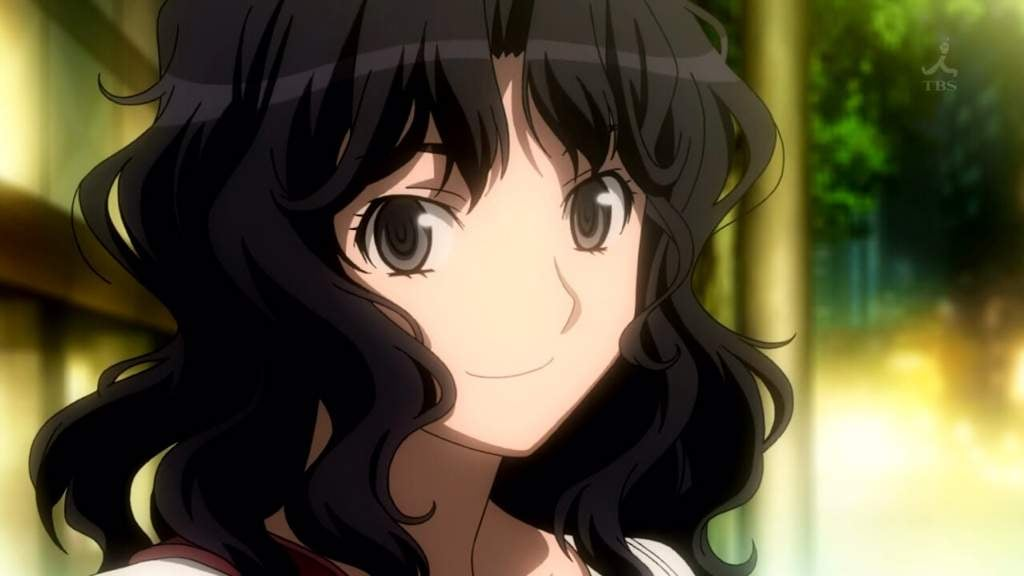

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 21ms/step
This image is 1.00 percent curly hair, 0.00 percent straight hair, and 0.00 percent wavy hair.


In [165]:
img = keras.preprocessing.image.load_img(
    "anime_hair_types/curly_hair/curly_anime_girl.jpg", target_size=image_size
)
img_array = keras.preprocessing.image.img_to_array(img)
img_array = tf.expand_dims(img_array, 0)  # Create batch axis

# Display the image and the results
print("Image:")
display(Image(filename="anime_hair_types/curly_hair/curly_anime_girl.jpg")) 

predictions = final_model.predict(img_array)

print(
    "This image is %.2f percent curly hair, %.2f percent straight hair, and %.2f percent wavy hair."
    % tuple(predictions[0])
)


Image:


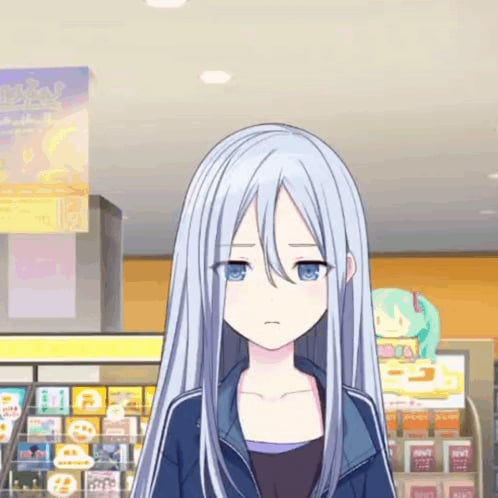

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 20ms/step
This image is 0.04 percent curly hair, 0.76 percent straight hair, and 0.20 percent wavy hair.


In [166]:
img = keras.preprocessing.image.load_img(
    "anime_hair_types/straight_hair/straight_anime_girl1.jpg", target_size=image_size
)
img_array = keras.preprocessing.image.img_to_array(img)
img_array = tf.expand_dims(img_array, 0)  # Create batch axis

# Display the image and the results
print("Image:")
display(Image(filename="anime_hair_types/straight_hair/straight_anime_girl1.jpg")) 

predictions = final_model.predict(img_array)

print(
    "This image is %.2f percent curly hair, %.2f percent straight hair, and %.2f percent wavy hair."
    % tuple(predictions[0])
)


Image:


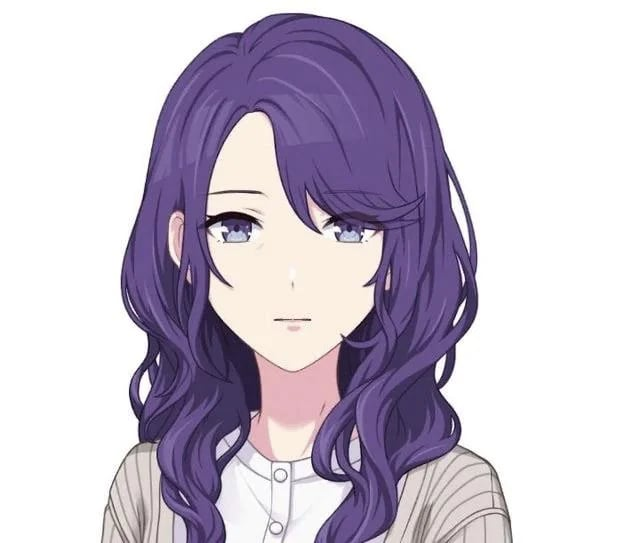

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step
This image is 0.12 percent curly hair, 0.88 percent straight hair, and 0.01 percent wavy hair.


In [167]:
img = keras.preprocessing.image.load_img(
    "anime_hair_types/wavy_hair/wavy_anime_girl.jpg", target_size=image_size
)
img_array = keras.preprocessing.image.img_to_array(img)
img_array = tf.expand_dims(img_array, 0)  # Create batch axis

# Display the image and the results
print("Image:")
display(Image(filename="anime_hair_types/wavy_hair/wavy_anime_girl.jpg")) 

predictions = final_model.predict(img_array)

print(
    "This image is %.2f percent curly hair, %.2f percent straight hair, and %.2f percent wavy hair."
    % tuple(predictions[0])
)
